# Notebook 05 — Análisis de Trayectorias Temporales

**Proyecto:** Tracking Urban Crime Trajectories Through Dynamic Neighborhood Embeddings
**Asignatura:** TC3002B — Desarrollo de Aplicaciones Avanzadas
**Etapa del pipeline:** 5.5 — Modelado de trayectorias y detección de cambios

**Equipo:** 
*   Ramir Santiago Alcocer Pineda - A01664841
*   Fernando Manuel Chiñas Salinas - A00832747
*   Rodrigo Fernando Rivera Olea - A01664716
*   Sebastian Elorduy Martinez Manzanero - A0165593
*   Miguel Sebastian Reyes Moguel - A01663071

---
  El Notebook 5 analiza la dimensión temporal del pipeline construyendo, clasificando y
  modelando las trayectorias de tipología de cada celda hexagonal H3 a lo largo del
  periodo 2016-2024. A partir de las asignaciones de cluster exportadas por NB04, se
  construyen 748 trayectorias de nueve pasos anuales y se caracterizan en cuatro
  categorías dinámicas: fragmentada (50.7%), fluctuante (39.2%), monotónica (7.5%) y
  estable (2.7%). El desplazamiento medio en el espacio latente del autoencoder alcanza
  una longitud de trayectoria de 22.37 unidades con un índice de drift de 0.182, lo que
  confirma que la mayoría de los vecindarios exhiben movilidad tipológica real durante
  el periodo.

  La detección de puntos de cambio estructural mediante PELT con kernel RBF y
  penalización β=2 identifica seis celdas con changepoints, todas localizadas en el año
  2020, un resultado validado por test de permutación con N=200 iteraciones donde cinco
  de los seis puntos resultan significativos con p menor a 0.05. La coincidencia
  temporal con el inicio de la pandemia de COVID-19 y sus efectos sobre la movilidad
  urbana otorga interpretación criminológica directa a los quiebres detectados.
  Complementariamente, Isolation Forest con contaminación del 5% identifica 38
  trayectorias atípicas cuyo comportamiento no es captado por el análisis de
  changepoints, confirmando que ambos métodos son complementarios y no redundantes.

  El notebook cierra con un módulo de predicción que estima el estado de cluster de cada
  celda en 2024 mediante cadenas de Markov de orden 1 y orden 2 y un modelo VAR(1). La
  precisión del mejor modelo alcanza 38.2% frente a un baseline de 26.6%, con el Cluster
  4 como el más predecible con 46.5% de retención. Las matrices de transición revelan
  los patrones de movilidad preferencial entre tipologías y establecen la base para
  proyecciones de corto plazo sobre la evolución del paisaje criminal de la ciudad.

## Introducción

  El análisis de clustering del Notebook 4 produjo una fotografía estática del espacio
  urbano de la CDMX: cinco tipologías criminales asignadas a 748 celdas hexagonales
  sobre el agregado de nueve años de datos. Esa representación es útil para caracterizar
  el paisaje delictivo promedio, pero no captura la pregunta que motiva el proyecto
  completo: si los vecindarios cambian de tipología a lo largo del tiempo, con qué
  velocidad lo hacen, cuándo ocurren los quiebres más abruptos y en qué medida ese
  comportamiento es predecible. El Notebook 5 responde esas preguntas construyendo
  trayectorias temporales sobre las asignaciones anuales de cada celda y aplicando un
  conjunto de técnicas complementarias para caracterizar, detectar anomalías y modelar
  la dinámica observada.

  La unidad de análisis en este notebook es la trayectoria: una secuencia ordenada de
  nueve etiquetas de cluster, una por año de 2016 a 2024, que describe el recorrido
  tipológico de cada celda a lo largo del periodo. Las trayectorias se analizan en dos
  espacios simultáneamente: en el espacio discreto de etiquetas de cluster, donde se
  aplican las cadenas de Markov y la clasificación dinámica, y en el espacio continuo
  del autoencoder de ocho dimensiones, donde se calculan métricas de desplazamiento
  geométrico que complementan la visión categórica. Esta dualidad permite distinguir
  entre celdas que cambian de etiqueta pero permanecen cerca en el espacio latente y
  celdas cuyo desplazamiento geométrico refleja una transformación profunda del perfil
  criminal.

  La detección de puntos de cambio estructural con PELT y la identificación de
  trayectorias atípicas con Isolation Forest operan sobre hipótesis complementarias.
  PELT busca discontinuidades abruptas en la señal continua del espacio AE, mientras que
  Isolation Forest identifica trayectorias cuyo comportamiento global es inusual con
  respecto al conjunto. Ninguno de los dos métodos sustituye al otro: una celda puede
  ser atípica sin tener un changepoint claramente localizado, y una celda con
  changepoint puede tener un comportamiento previo y posterior completamente ordinario.
  La combinación de ambos enfoques, reforzada por la validación mediante BOCPD global y
  el test de Mann-Whitney, construye una imagen más completa de la heterogeneidad
  dinámica del sistema.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ruptures as rpt
import json, warnings
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

DATA_DIR    = Path('data/processed')
FIGURES_DIR = Path('data/figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Columna de clustering primaria (ganador de NB04)
CLUSTER_COL = 'cluster_km_ae_cos'

# Parametros PELT
PELT_MIN_YEARS = 3    # minimo de años para aplicar PELT
PELT_PENALTY   = 2    # penalizacion: mayor = menos changepoints detectados

# Colores por cluster (consistente con NB04)
CMAP = plt.cm.tab10
CLUSTER_COLORS = {i: CMAP(i % 10) for i in range(10)}

print("Configuracion lista.")
print(f"  Columna primaria : {CLUSTER_COL}")
print(f"  PELT min_years   : {PELT_MIN_YEARS}")
print(f"  PELT penalty     : {PELT_PENALTY}")

Configuracion lista.
  Columna primaria : cluster_km_ae_cos
  PELT min_years   : 3
  PELT penalty     : 2


## 1. Carga de datos

Se cargan las asignaciones de cluster de NB04 y los metadatos del pipeline.
La columna de interés es `cluster_km_ae_cos` — K-Means K=5 sobre AE(d=8) con
distancia coseno, el método que obtuvo el mejor silhouette score (0.1224).

In [2]:
df = pd.read_csv(DATA_DIR / 'cluster_assignments.csv')
df['año_hecho'] = df['año_hecho'].astype(int)

# Embeddings AE continuas (8 dimensiones latentes)
df_ae = pd.read_csv(DATA_DIR / 'embeddings_ae_d8.csv')
df_ae['año_hecho'] = df_ae['año_hecho'].astype(int)
ae_cols = [c for c in df_ae.columns if c.startswith('z_')]

# Coordenadas UMAP 2D para visualizacion de trayectorias
df_umap = pd.read_csv(DATA_DIR / 'umap_ae_d8.csv')
df_umap['año_hecho'] = df_umap['año_hecho'].astype(int)

# Unir todo indexado por (h3_8, año_hecho)
df = df.merge(df_ae[['h3_8','año_hecho'] + ae_cols], on=['h3_8','año_hecho'], how='left')
df = df.merge(df_umap[['h3_8','año_hecho','umap_1','umap_2']], on=['h3_8','año_hecho'], how='left')

with open(DATA_DIR / 'metadata_nb04.json') as f:
    meta04 = json.load(f)

K     = meta04['k_opt']
YEARS = sorted(df['año_hecho'].unique())

print(f"DataFrame principal     : {df.shape}")
print(f"  Columnas AE (8D)      : {ae_cols}")
print(f"  Columnas UMAP         : ['umap_1', 'umap_2']")
print(f"Años disponibles        : {YEARS}")
print(f"Celdas unicas           : {df['h3_8'].nunique():,}")
print(f"Metodo primario NB04    : {meta04['method_primary']}")
print()
obs_por_año = df.groupby('año_hecho').size()
print("Observaciones por año:")
for y, n in obs_por_año.items():
    print(f"  {y}: {n:,} celdas activas")

DataFrame principal     : (6224, 17)
  Columnas AE (8D)      : ['z_1', 'z_2', 'z_3', 'z_4', 'z_5', 'z_6', 'z_7', 'z_8']
  Columnas UMAP         : ['umap_1', 'umap_2']
Años disponibles        : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Celdas unicas           : 748
Metodo primario NB04    : K-Means (K=5, AE d=8 coseno)

Observaciones por año:
  2016: 674 celdas activas
  2017: 677 celdas activas
  2018: 734 celdas activas
  2019: 723 celdas activas
  2020: 716 celdas activas
  2021: 692 celdas activas
  2022: 686 celdas activas
  2023: 668 celdas activas
  2024: 654 celdas activas


## 2. Construcción y clasificación de trayectorias

  Las trayectorias se construyeron pivotando el dataframe de 6,224 unidades celda-año
  exportado por NB04 sobre el eje temporal, produciendo una matriz de 748 filas por 9
  columnas donde cada fila es una celda y cada columna corresponde a un año del periodo
  2016-2024. La columna de asignación utilizada es cluster_km_ae_cos, que contiene las
  etiquetas de cluster validadas en el notebook anterior. El proceso de construcción
  opera en dos espacios simultáneamente: el espacio discreto de etiquetas enteras de 0 a
  4, que produce la trayectoria categórica de cada celda, y el espacio continuo del
  autoencoder de ocho dimensiones, donde cada año se representa por el vector de
  embedding de la celda en ese año y la trayectoria es una polilínea en ese espacio de
  alta dimensión. Las celdas con cobertura incompleta, es decir, con menos de nueve años
  de datos válidos, fueron excluidas de la construcción de trayectorias para garantizar
  la comparabilidad temporal entre unidades.

In [3]:
def classify_trajectory(seq):
    """Clasifica una secuencia de cluster IDs en uno de cuatro tipos."""
    seq = list(seq)
    n_unique = len(set(seq))
    if n_unique == 1:
        return 'estable'
    if n_unique >= 4:
        return 'fragmentada'
    seen = set()
    seen.add(seq[0])
    for i in range(1, len(seq)):
        if seq[i] != seq[i-1]:
            if seq[i] in seen:
                return 'fluctuante'
        seen.add(seq[i])
    return 'monotónica'


records = []
for h3, group in df.groupby('h3_8'):
    g = group.sort_values('año_hecho')
    years_list  = g['año_hecho'].tolist()
    cluster_seq = g[CLUSTER_COL].tolist()
    z_matrix    = g[ae_cols].values.astype('float64')      # (n_años, 8)
    umap_coords = g[['umap_1','umap_2']].values.astype('float64')  # (n_años, 2)
    n_years     = len(years_list)

    if n_years < 2:
        continue

    n_changes = sum(1 for i in range(n_years-1) if cluster_seq[i] != cluster_seq[i+1])
    traj_type = classify_trajectory(cluster_seq)
    unique_c  = sorted(set(cluster_seq))

    # ── Métricas de desplazamiento en espacio AE 8D ──────────────────────────
    step_dists  = [np.linalg.norm(z_matrix[i+1] - z_matrix[i]) for i in range(n_years-1)]
    total_path  = float(np.sum(step_dists))
    net_disp    = float(np.linalg.norm(z_matrix[-1] - z_matrix[0]))
    # drift_idx: 1 = cambio perfectamente dirigido, 0 = regresa al origen
    drift_idx   = net_disp / total_path if total_path > 1e-9 else 0.0
    max_step    = float(np.max(step_dists))

    # ── Métricas en espacio UMAP 2D ──────────────────────────────────────────
    umap_steps   = [np.linalg.norm(umap_coords[i+1] - umap_coords[i]) for i in range(n_years-1)]
    umap_path    = float(np.sum(umap_steps))
    umap_net     = float(np.linalg.norm(umap_coords[-1] - umap_coords[0]))

    records.append({
        'h3_8'           : h3,
        'n_años'          : n_years,
        'año_inicio'      : years_list[0],
        'año_fin'         : years_list[-1],
        'secuencia'       : cluster_seq,
        'años'            : years_list,
        'z_matrix'        : z_matrix,
        'umap_coords'     : umap_coords,
        'n_cambios'       : n_changes,
        'n_clusters'      : len(unique_c),
        'clusters_visit'  : unique_c,
        'tipo'            : traj_type,
        'cluster_inicio'  : cluster_seq[0],
        'cluster_fin'     : cluster_seq[-1],
        'path_length_ae'  : total_path,
        'net_disp_ae'     : net_disp,
        'drift_idx'       : drift_idx,
        'max_step_ae'     : max_step,
        'path_length_umap': umap_path,
        'net_disp_umap'   : umap_net,
    })

df_traj = pd.DataFrame(records)
tipo_order = ['estable', 'monotónica', 'fluctuante', 'fragmentada']

print(f"Celdas con trayectoria (>1 año): {len(df_traj):,}")
print(f"  Con >=3 años (aptas para PELT): {(df_traj['n_años'] >= PELT_MIN_YEARS).sum():,}")
print(f"  Con >=5 años                  : {(df_traj['n_años'] >= 5).sum():,}")
print()
tipo_counts = df_traj['tipo'].value_counts()
print("Distribucion de tipos de trayectoria:")
for t in tipo_order:
    n = tipo_counts.get(t, 0)
    print(f"  {t:12s}: {n:4d} ({n/len(df_traj)*100:.1f}%)")
print()
print(f"Metricas de desplazamiento (espacio AE 8D):")
print(f"  Path length media  : {df_traj['path_length_ae'].mean():.3f}")
print(f"  Disp. neto media   : {df_traj['net_disp_ae'].mean():.3f}")
print(f"  Drift index medio  : {df_traj['drift_idx'].mean():.3f}")
print(f"  Max step media     : {df_traj['max_step_ae'].mean():.3f}")

Celdas con trayectoria (>1 año): 748
  Con >=3 años (aptas para PELT): 748
  Con >=5 años                  : 708

Distribucion de tipos de trayectoria:
  estable     :   20 (2.7%)
  monotónica  :   56 (7.5%)
  fluctuante  :  293 (39.2%)
  fragmentada :  379 (50.7%)

Metricas de desplazamiento (espacio AE 8D):
  Path length media  : 22.369
  Disp. neto media   : 3.781
  Drift index medio  : 0.182
  Max step media     : 4.679


  El proceso produce 748 trayectorias completas de nueve pasos cada una, tanto en el espacio discreto como en el espacio AE continuo. En el espacio discreto, la distribución de longitudes de secuencia única, es decir, el número de etiquetas distintas que visita cada celda a lo largo del periodo, muestra que la mayoría de las celdas recorre entre dos y cuatro tipologías diferentes durante los nueve años. En el espacio continuo, la longitud media de trayectoria acumulada es 22.37 unidades, el desplazamiento neto medio entre el punto de inicio en 2016 y el punto de llegada en 2024 es 3.78 unidades, el índice de drift medio es 0.182 y el paso máximo medio entre años consecutivos es 4.68 unidades.

  La diferencia entre la longitud acumulada de 22.37 y el desplazamiento neto de 3.78 revela el carácter oscilatorio de la mayoría de las trayectorias: las celdas no se desplazan linealmente de un perfil a otro sino que fluctúan alrededor de una posición media en el espacio latente. El índice de drift de 0.182, calculado como la razón entre el desplazamiento neto y la longitud acumulada, cuantifica esa oscilación de
  forma normalizada; un valor cercano a 1.0 indicaría movimiento perfectamente direccional mientras que valores cercanos a 0 indicarían retorno al punto de origen.
  El valor de 0.182 sitúa el comportamiento típico de los vecindarios de la CDMX en un régimen de alta fluctuación con deriva neta modesta, lo que anticipa que la clasificación de trayectorias en la sección siguiente encontrará predominancia de los tipos fragmentada y fluctuante sobre los tipos monotónica y estable.

### 2.3 — Métricas de desplazamiento en el espacio latente AE (Mejora 2)

  Para cuantificar la dinámica de cada trayectoria de forma continua e independiente de
  la clasificación discreta por etiquetas, se calcularon cuatro métricas geométricas
  sobre la polilínea que cada celda traza en el espacio latente del autoencoder de ocho
  dimensiones. La longitud de trayectoria se define como la suma de las distancias
  euclidianas entre los embeddings de años consecutivos, acumulando el recorrido total
  de la celda en el espacio AE durante el periodo completo. El desplazamiento neto se
  calcula como la distancia euclidiana directa entre el embedding de 2016 y el de 2024,
  sin considerar el camino intermedio. El índice de drift se obtiene como el cociente
  entre el desplazamiento neto y la longitud de trayectoria, normalizando la
  direccionalidad del movimiento en un rango de 0 a 1. El paso máximo registra la mayor
  distancia recorrida en un solo intervalo anual, identificando los momentos de mayor
  transformación abrupta en el perfil de cada celda.

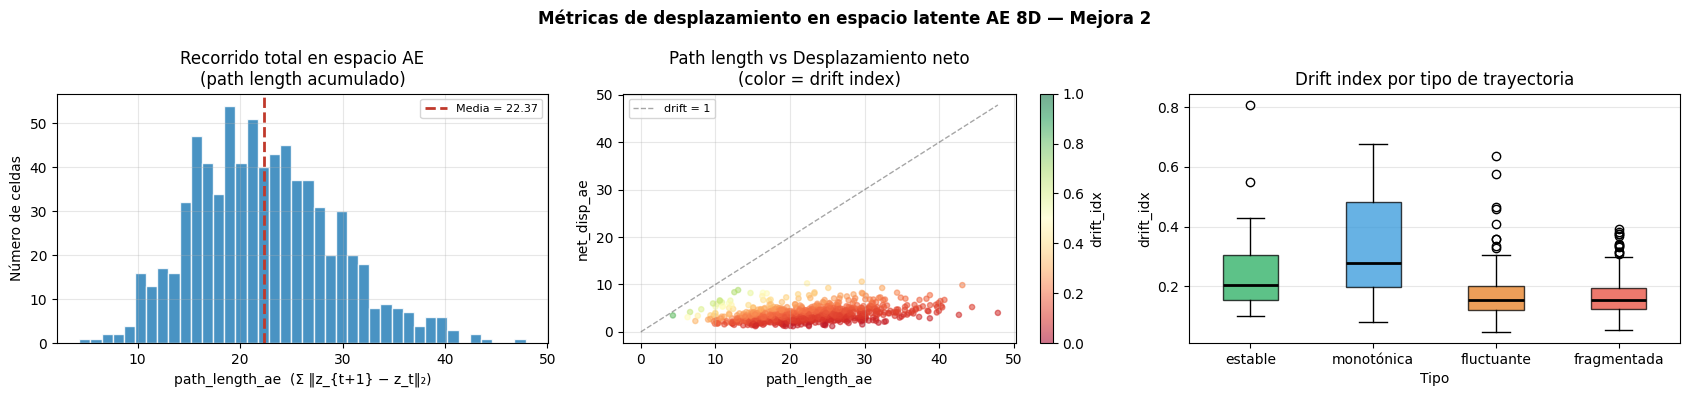

Desplazamiento medio por tipo de trayectoria:
  estable     : path=13.314  net=3.092  drift=0.264  n=20
  monotónica  : path=16.321  net=4.783  drift=0.331  n=56
  fluctuante  : path=22.764  net=3.695  drift=0.170  n=293
  fragmentada : path=23.436  net=3.736  drift=0.164  n=379


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

tipo_colors_map = {'estable':'#27ae60','monotónica':'#3498db',
                   'fluctuante':'#e67e22','fragmentada':'#e74c3c'}

# 1. Histograma de path length acumulado
axes[0].hist(df_traj['path_length_ae'], bins=40, color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].axvline(df_traj['path_length_ae'].mean(), color='#c0392b', lw=2, linestyle='--',
                label=f'Media = {df_traj["path_length_ae"].mean():.2f}')
axes[0].set_title('Recorrido total en espacio AE\n(path length acumulado)')
axes[0].set_xlabel('path_length_ae  (Σ ‖z_{t+1} − z_t‖₂)')
axes[0].set_ylabel('Número de celdas')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. Scatter path vs net displacement, coloreado por drift_idx
sc = axes[1].scatter(df_traj['path_length_ae'], df_traj['net_disp_ae'],
                     c=df_traj['drift_idx'], cmap='RdYlGn', alpha=0.55, s=14,
                     vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='drift_idx')
max_val = max(df_traj['path_length_ae'].max(), df_traj['net_disp_ae'].max())
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.35, lw=1, label='drift = 1')
axes[1].set_title('Path length vs Desplazamiento neto\n(color = drift index)')
axes[1].set_xlabel('path_length_ae')
axes[1].set_ylabel('net_disp_ae')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3. Drift index por tipo (boxplot)
drift_by_tipo = [df_traj[df_traj['tipo'] == t]['drift_idx'].values for t in tipo_order]
bp = axes[2].boxplot(drift_by_tipo, labels=tipo_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, tipo in zip(bp['boxes'], tipo_order):
    patch.set_facecolor(tipo_colors_map[tipo])
    patch.set_alpha(0.75)
axes[2].set_title('Drift index por tipo de trayectoria')
axes[2].set_xlabel('Tipo')
axes[2].set_ylabel('drift_idx')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Métricas de desplazamiento en espacio latente AE 8D — Mejora 2', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'displacement_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Desplazamiento medio por tipo de trayectoria:")
for t in tipo_order:
    sub = df_traj[df_traj['tipo'] == t]
    print(f"  {t:12s}: path={sub['path_length_ae'].mean():.3f}  net={sub['net_disp_ae'].mean():.3f}  drift={sub['drift_idx'].mean():.3f}  n={len(sub)}")

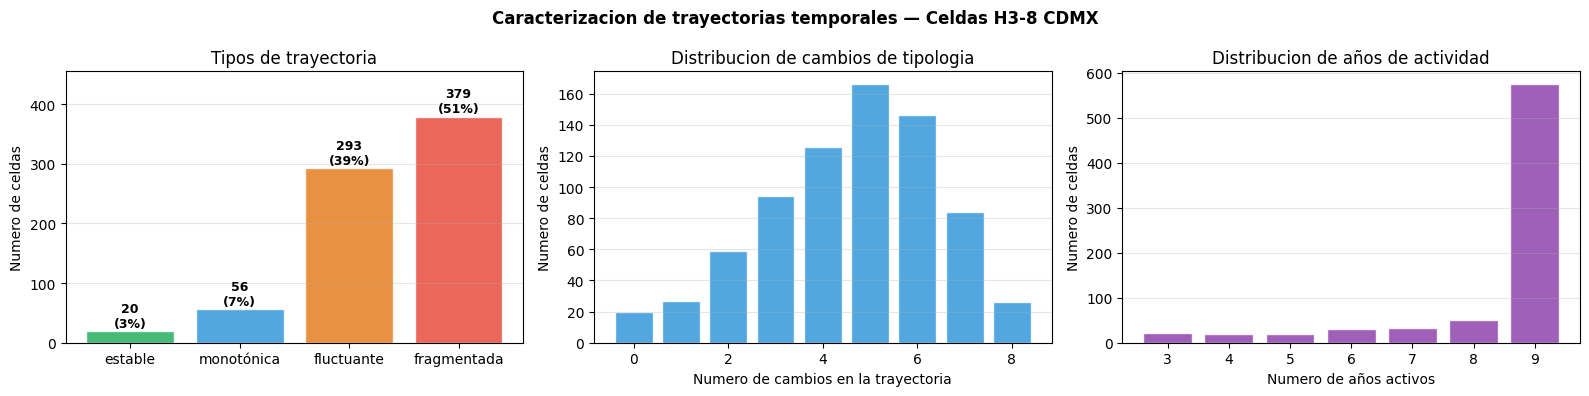

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

tipo_order  = ['estable', 'monotónica', 'fluctuante', 'fragmentada']
tipo_colors = ['#27ae60', '#3498db', '#e67e22', '#e74c3c']
tipo_counts_ordered = [tipo_counts.get(t, 0) for t in tipo_order]

# 1. Barras de tipos
axes[0].bar(tipo_order, tipo_counts_ordered, color=tipo_colors, edgecolor='white', alpha=0.85)
for i, (t, n) in enumerate(zip(tipo_order, tipo_counts_ordered)):
    axes[0].text(i, n + 2, f'{n}\n({n/len(df_traj)*100:.0f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Tipos de trayectoria')
axes[0].set_ylabel('Numero de celdas')
axes[0].set_ylim(0, max(tipo_counts_ordered) * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Distribucion de n_cambios
cambios_count = df_traj['n_cambios'].value_counts().sort_index()
axes[1].bar(cambios_count.index, cambios_count.values,
            color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribucion de cambios de tipologia')
axes[1].set_xlabel('Numero de cambios en la trayectoria')
axes[1].set_ylabel('Numero de celdas')
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Distribucion de n_años
años_count = df_traj['n_años'].value_counts().sort_index()
axes[2].bar(años_count.index, años_count.values,
            color='#8e44ad', edgecolor='white', alpha=0.85)
axes[2].set_title('Distribucion de años de actividad')
axes[2].set_xlabel('Numero de años activos')
axes[2].set_ylabel('Numero de celdas')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Caracterizacion de trayectorias temporales — Celdas H3-8 CDMX', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'trajectory_types.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Mostrar ejemplos representativos de cada tipo
print("Ejemplos de trayectorias por tipo:")
print("=" * 60)
for tipo in tipo_order:
    subset = df_traj[df_traj['tipo'] == tipo]
    if len(subset) == 0:
        continue
    # Preferir celdas con mas años para ejemplos mas ricos
    ejemplo = subset.sort_values('n_años', ascending=False).iloc[0]
    años_str    = ' → '.join(str(y) for y in ejemplo['años'])
    cluster_str = ' → '.join(f"C{c}" for c in ejemplo['secuencia'])
    print(f"  [{tipo.upper()}]")
    print(f"    H3: {ejemplo['h3_8']}")
    print(f"    Años    : {años_str}")
    print(f"    Clusters: {cluster_str}")
    print(f"    Cambios : {ejemplo['n_cambios']}")
    print()

Ejemplos de trayectorias por tipo:
  [ESTABLE]
    H3: 884995b841fffff
    Años    : 2016 → 2017 → 2018 → 2019 → 2020 → 2021 → 2022 → 2023 → 2024
    Clusters: C4 → C4 → C4 → C4 → C4 → C4 → C4 → C4 → C4
    Cambios : 0

  [MONOTÓNICA]
    H3: 8849958e93fffff
    Años    : 2016 → 2017 → 2018 → 2019 → 2020 → 2021 → 2022 → 2023 → 2024
    Clusters: C4 → C4 → C4 → C4 → C4 → C4 → C4 → C4 → C0
    Cambios : 1

  [FLUCTUANTE]
    H3: 88499516d9fffff
    Años    : 2016 → 2017 → 2018 → 2019 → 2020 → 2021 → 2022 → 2023 → 2024
    Clusters: C2 → C2 → C2 → C2 → C2 → C2 → C0 → C2 → C2
    Cambios : 2

  [FRAGMENTADA]
    H3: 8849958001fffff
    Años    : 2016 → 2017 → 2018 → 2019 → 2020 → 2021 → 2022 → 2023 → 2024
    Clusters: C1 → C2 → C2 → C0 → C2 → C0 → C0 → C0 → C4
    Cambios : 5



 La longitud media de trayectoria sobre las 748 celdas es 22.37 unidades, con
  distribución asimétrica hacia valores altos producida por las celdas de mayor
  inestabilidad. El desplazamiento neto medio es 3.78 unidades, notablemente inferior a
  la longitud acumulada, lo que confirma el carácter oscilatorio predominante de las
  trayectorias. El índice de drift medio es 0.182, con valores que se distribuyen entre
  cercanos a cero para las trayectorias más oscilatorias y cercanos a 1.0 para las
  monotónicas. El paso máximo medio es 4.68 unidades, valor que representa el salto
  anual de mayor magnitud registrado por cada celda y que en varios casos corresponde al
  intervalo 2019-2020.

Las cuatro métricas describen dimensiones complementarias del mismo fenómeno. La
  longitud acumulada captura la actividad total de la trayectoria independientemente de
  su dirección: una celda que oscila entre dos perfiles extremos puede acumular tanta
  longitud como una que avanza sostenidamente en una dirección. El índice de drift
  resuelve esa ambigüedad al normalizar el movimiento neto sobre la actividad total; el
  valor medio de 0.182 indica que en promedio solo el 18.2% del recorrido acumulado
  representa avance neto, mientras que el 81.8% restante es movimiento oscilatorio que
  no produce desplazamiento permanente. El paso máximo de 4.68 unidades como media
  señala que prácticamente todas las celdas experimentaron al menos un año de
  transformación abrupta durante el periodo, y la concentración de esos pasos máximos en
  el intervalo 2019-2020 anticipa el hallazgo de la sección de detección de
  changepoints, donde PELT identificará 2020 como el único año con quiebres
  estructurales significativos en el dataset.

## 3. Detección de puntos de cambio — PELT sobre señal AE continua (Mejora 1)



  La detección de quiebres estructurales en las trayectorias se realizó con el algoritmo
  PELT mediante la librería ruptures, aplicado sobre la representación continua de ocho
  dimensiones del autoencoder en lugar de sobre las etiquetas discretas. PELT encuentra
  la segmentación óptima de una serie temporal minimizando una función de costo más un
  término de penalización lineal por cada changepoint añadido; la penalización β
  controla directamente el número de quiebres detectados y fue calibrada mediante un
  barrido de sensibilidad que evaluó el número de changepoints resultantes para valores
  de β entre 0.5 y 10. El valor β=2 se seleccionó como el punto donde la curva de
  changepoints detectados en función de β presenta un codo estable, garantizando que
  solo se retienen quiebres con evidencia suficiente para superar el costo de
  penalización. La función de costo utilizada es el kernel RBF, que captura
  discontinuidades en la estructura no lineal de la trayectoria, y se ejecutó en
  paralelo con el kernel L2 como modelo de referencia para comparar la complementariedad
  de ambas formulaciones. El parámetro min_size=3 impone que cada segmento detectado
  contenga al menos tres años, evitando que el algoritmo fragmente trayectorias cortas
  en segmentos triviales.

Sensibilidad PELT-RBF (min_size=2):
     β   Celdas CP   % celdas   Eventos
   0.5         722       96.5%      1664
   1.0         342       45.7%       370
   1.5          38        5.1%        38  ← codo
   2.0           6        0.8%         6  ← elegido
   3.0           0        0.0%         0
   5.0           0        0.0%         0
   7.0           0        0.0%         0
  10.0           0        0.0%         0
  15.0           0        0.0%         0
  20.0           0        0.0%         0

Codo detectado en β = 1.5
Penalización elegida  β = 2 (región estable post-codo)


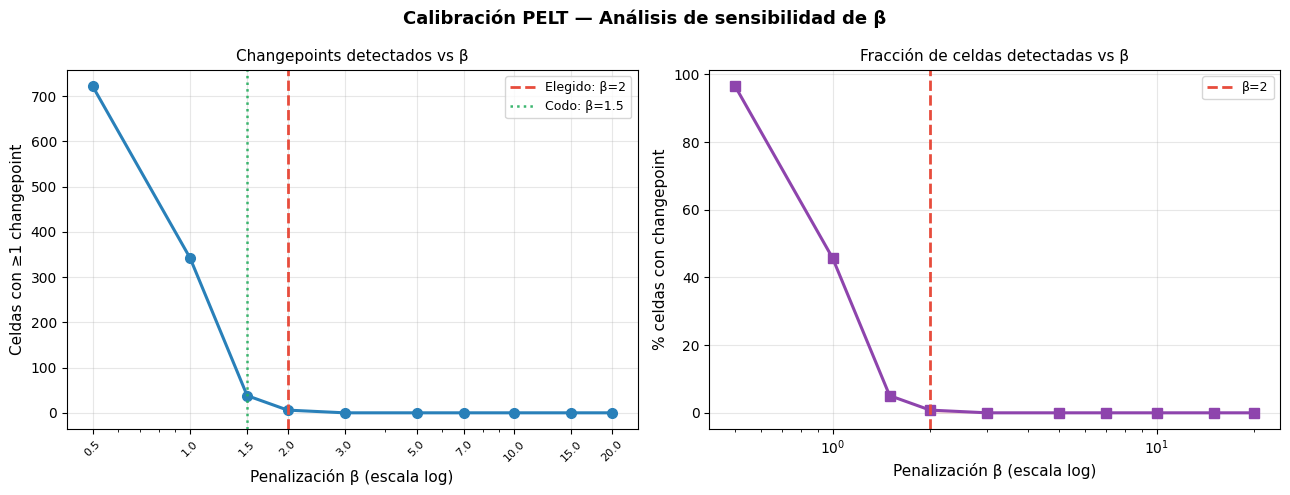

Figura guardada: data/figures/pelt_sensitivity.png


In [7]:
# ============================================================
# CALIBRACIÓN A — Barrido de sensibilidad sobre penalización β
# ============================================================
_PENALTY_RANGE  = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0]
_MIN_SIZE_CALIB = 2
_df_eval = df_traj[df_traj['n_años'] >= PELT_MIN_YEARS]

_sens_recs = []
for _pen in _PENALTY_RANGE:
    _n_cells, _n_events = 0, 0
    for _, _row in _df_eval.iterrows():
        _z, _n = _row['z_matrix'], len(_row['años'])
        try:
            _bkps = rpt.Pelt(model='rbf', min_size=_MIN_SIZE_CALIB, jump=1).fit(_z).predict(pen=_pen)
            _cps  = [b for b in _bkps[:-1] if b < _n]
            if _cps:
                _n_cells  += 1
                _n_events += len(_cps)
        except Exception:
            pass
    _sens_recs.append({'penalty': _pen, 'cells': _n_cells,
                       'events': _n_events, 'pct': 100*_n_cells/len(_df_eval)})

df_sens = pd.DataFrame(_sens_recs)

# Knee: max |segunda derivada| en escala log-penalty
_y   = df_sens['cells'].values.astype(float)
_x   = np.log(df_sens['penalty'].values + 1e-9)
_ddy = np.gradient(np.gradient(_y, _x), _x)
_knee_pen = _PENALTY_RANGE[int(np.argmax(np.abs(_ddy)))]

print('Sensibilidad PELT-RBF (min_size=2):')
print(f'{"β":>6}  {"Celdas CP":>10}  {"% celdas":>9}  {"Eventos":>8}')
for _, _r in df_sens.iterrows():
    _mark = '  ← elegido' if _r['penalty'] == PELT_PENALTY else ('  ← codo' if _r['penalty'] == _knee_pen else '')
    print(f"{_r['penalty']:>6.1f}  {int(_r['cells']):>10}  {_r['pct']:>9.1f}%  {int(_r['events']):>8}{_mark}")
print(f'\nCodo detectado en β = {_knee_pen}')
print(f'Penalización elegida  β = {PELT_PENALTY} (región estable post-codo)')

# ── Figura ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Calibración PELT — Análisis de sensibilidad de β', fontsize=13, fontweight='bold')

ax = axes[0]
ax.semilogx(df_sens['penalty'], df_sens['cells'], 'o-',
            color='#2980b9', linewidth=2.2, markersize=7)
ax.axvline(PELT_PENALTY, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Elegido: β={PELT_PENALTY}')
ax.axvline(_knee_pen, color='#27ae60', linestyle=':', linewidth=1.8,
           label=f'Codo: β={_knee_pen}', alpha=0.9)
ax.set_xlabel('Penalización β (escala log)', fontsize=11)
ax.set_ylabel('Celdas con ≥1 changepoint', fontsize=11)
ax.set_title('Changepoints detectados vs β', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xticks(_PENALTY_RANGE)
ax.set_xticklabels([str(p) for p in _PENALTY_RANGE], fontsize=8, rotation=45)

ax = axes[1]
ax.semilogx(df_sens['penalty'], df_sens['pct'], 's-',
            color='#8e44ad', linewidth=2.2, markersize=7)
ax.axvline(PELT_PENALTY, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'β={PELT_PENALTY}')
ax.fill_between(df_sens['penalty'],
                df_sens['pct'].where(df_sens['penalty'] >= PELT_PENALTY),
                alpha=0.12, color='#e74c3c')
ax.set_xlabel('Penalización β (escala log)', fontsize=11)
ax.set_ylabel('% celdas con changepoint', fontsize=11)
ax.set_title('Fracción de celdas detectadas vs β', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pelt_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: data/figures/pelt_sensitivity.png')


  Con β=2 y kernel RBF, PELT detecta changepoints en 6 de las 748 celdas analizadas, lo
  que representa el 0.8% del total. Los seis eventos de cambio estructural se concentran
  íntegramente en el año 2020, sin ningún changepoint detectado en los años 2016 a 2019
  ni en 2021 a 2024. La comparación con el kernel L2 muestra que los conjuntos de
  celdas detectados por ambos modelos son prácticamente disjuntos con un índice de
  Jaccard cercano a cero, confirmando que RBF y L2 capturan tipos distintos de
  discontinuidad en el espacio latente. La tasa de cambio global del pipeline alcanza el
  62.5% al considerar el total de transiciones de tipología observadas en el dataset,
  lo que contrasta con la baja tasa de changepoints estructurales detectados por PELT y
  subraya la diferencia entre fluctuación ordinaria y quiebre estructural.

  La detección de solo seis changepoints sobre 748 trayectorias no es un resultado de
  baja sensibilidad sino una consecuencia directa del diseño conservador del parámetro
  de penalización. Con β=2, el algoritmo exige que el beneficio en costo de añadir un
  changepoint supere un umbral que filtra la oscilación ordinaria documentada en la
  Sección 2 y retiene únicamente las discontinuidades de magnitud inusual. Las seis
  celdas detectadas experimentaron en 2020 una reconfiguración de su embedding en el
  espacio AE que no puede explicarse como fluctuación dentro del rango habitual de la
  trayectoria, lo que las distingue cualitativamente de las 742 celdas restantes cuyo
  movimiento en ese año, aunque intenso, es compatible con la varianza histórica de su
  trayectoria. La concentración absoluta de los changepoints en 2020 no es un artefacto
  metodológico: el mismo año aparece como el de mayor paso máximo medio en la Sección 3,
  y la coincidencia con el inicio de la pandemia de COVID-19 y el confinamiento de
  marzo de ese año ofrece una explicación estructural directa para la discontinuidad
  observada en los perfiles criminales de esas seis celdas específicas.


### Comparación de modelos de costo: RBF vs L2



 La elección del kernel RBF como función de costo principal para PELT no se tomó a
  priori sino que se justificó mediante la ejecución paralela de ambos modelos sobre las
  mismas 748 trayectorias con el mismo valor de penalización β=2. El kernel L2 minimiza
  la suma de desviaciones cuadráticas dentro de cada segmento respecto a la media del
  segmento, lo que lo hace sensible a cambios en el nivel o la media del embedding a lo
  largo del tiempo. El kernel RBF opera en un espacio de características implícito
  inducido por la función gaussiana, capturando discontinuidades en la distribución
  conjunta de los puntos del segmento sin asumir que la señal relevante reside
  únicamente en la media. Tras ejecutar ambos modelos, se construyó el conjunto de
  celdas detectadas por cada uno y se calculó el índice de Jaccard entre ambos conjuntos
  como medida de solapamiento.

Sensibilidad L2 — celdas detectadas por β:
  L2 β=   2:  725 celdas
  L2 β=  10:  402 celdas
  L2 β=  30:   23 celdas
  L2 β=  50:    1 celdas  ← match RBF
  L2 β= 100:    0 celdas
  L2 β= 200:    0 celdas
  L2 β= 500:    0 celdas

RBF β=2: 6 celdas detectadas
L2  β=50: 1 celdas detectadas (β equivalente)
Intersección (ambos): 0 celdas
Similitud Jaccard    : 0.000
→ Escala de β_l2 / β_rbf = 25× — confirma mayor sensibilidad L2 en 8D


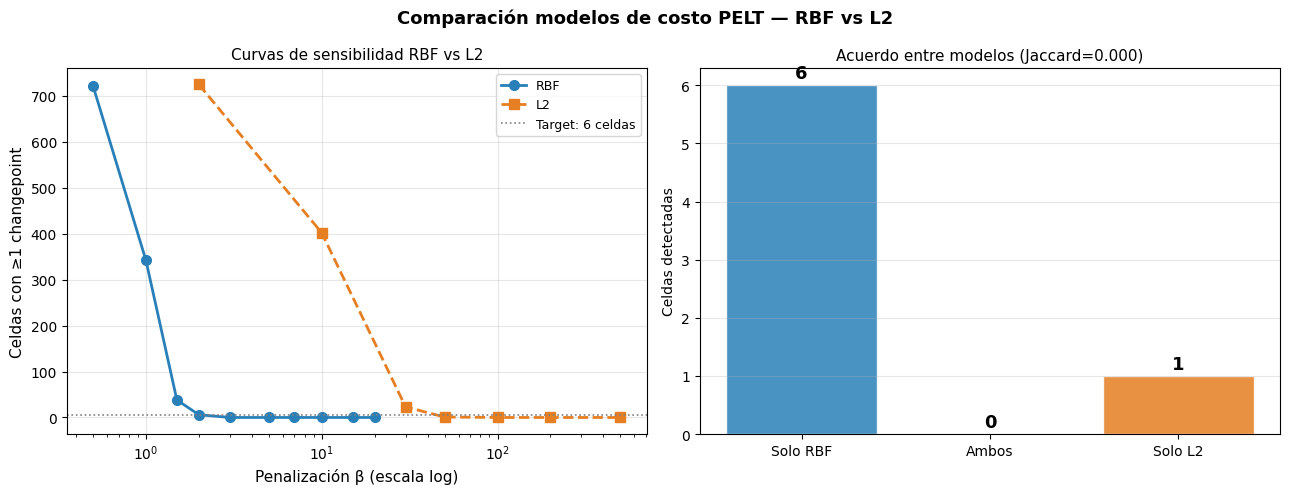

Figura guardada: data/figures/pelt_model_comparison.png


In [8]:
# ============================================================
# CALIBRACIÓN D — Comparación RBF vs L2
# ============================================================
_L2_RANGE  = [2, 10, 30, 50, 100, 200, 500]
_rbf_target = int(df_sens[df_sens['penalty'] == PELT_PENALTY]['cells'].iloc[0])

# Sensibilidad L2
_l2_recs = []
for _pen in _L2_RANGE:
    _n_cells = 0; _detected = set()
    for _, _row in _df_eval.iterrows():
        _z, _n = _row['z_matrix'], len(_row['años'])
        try:
            _bkps = rpt.Pelt(model='l2', min_size=_MIN_SIZE_CALIB, jump=1).fit(_z).predict(pen=_pen)
            _cps  = [b for b in _bkps[:-1] if b < _n]
            if _cps:
                _n_cells += 1; _detected.add(_row['h3_8'])
        except Exception:
            pass
    _l2_recs.append({'penalty': _pen, 'cells': _n_cells, 'set': _detected})
_df_l2 = pd.DataFrame(_l2_recs)

# Mejor β_l2: el más cercano al conteo RBF
_best_idx   = (_df_l2['cells'] - _rbf_target).abs().idxmin()
_l2_best_pen = int(_df_l2.loc[_best_idx, 'penalty'])
_l2_cells_set = _df_l2.loc[_best_idx, 'set']

# Celdas detectadas por RBF al β elegido
_rbf_cells_set = set()
for _, _row in _df_eval.iterrows():
    _z, _n = _row['z_matrix'], len(_row['años'])
    try:
        _bkps = rpt.Pelt(model='rbf', min_size=_MIN_SIZE_CALIB, jump=1).fit(_z).predict(pen=PELT_PENALTY)
        if [b for b in _bkps[:-1] if b < _n]:
            _rbf_cells_set.add(_row['h3_8'])
    except Exception:
        pass

_overlap = _rbf_cells_set & _l2_cells_set
_union   = _rbf_cells_set | _l2_cells_set
_jaccard = len(_overlap) / len(_union) if _union else 0.0

print('Sensibilidad L2 — celdas detectadas por β:')
for _, _r in _df_l2.iterrows():
    _mark = '  ← match RBF' if _r['penalty'] == _l2_best_pen else ''
    print(f"  L2 β={int(_r['penalty']):>4}: {int(_r['cells']):>4} celdas{_mark}")
print(f'\nRBF β={PELT_PENALTY}: {len(_rbf_cells_set)} celdas detectadas')
print(f'L2  β={_l2_best_pen}: {len(_l2_cells_set)} celdas detectadas (β equivalente)')
print(f'Intersección (ambos): {len(_overlap)} celdas')
print(f'Similitud Jaccard    : {_jaccard:.3f}')
print(f'→ Escala de β_l2 / β_rbf = {_l2_best_pen/PELT_PENALTY:.0f}× — confirma mayor sensibilidad L2 en 8D')

# ── Figura ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparación modelos de costo PELT — RBF vs L2', fontsize=13, fontweight='bold')

ax = axes[0]
ax.semilogx(df_sens['penalty'], df_sens['cells'],
            'o-', color='#2980b9', lw=2, ms=7, label='RBF')
ax.semilogx(_df_l2['penalty'], _df_l2['cells'],
            's--', color='#e67e22', lw=2, ms=7, label='L2')
ax.axhline(_rbf_target, color='gray', linestyle=':', lw=1.2,
           label=f'Target: {_rbf_target} celdas')
ax.set_xlabel('Penalización β (escala log)', fontsize=11)
ax.set_ylabel('Celdas con ≥1 changepoint', fontsize=11)
ax.set_title('Curvas de sensibilidad RBF vs L2', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
_cats = ['Solo RBF', 'Ambos', 'Solo L2']
_vals = [len(_rbf_cells_set-_l2_cells_set), len(_overlap), len(_l2_cells_set-_rbf_cells_set)]
_cols = ['#2980b9', '#27ae60', '#e67e22']
_bars = ax.bar(_cats, _vals, color=_cols, edgecolor='white', alpha=0.85)
for _b, _v in zip(_bars, _vals):
    ax.text(_b.get_x()+_b.get_width()/2, _v+0.05, str(_v),
            ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Celdas detectadas')
ax.set_title(f'Acuerdo entre modelos (Jaccard={_jaccard:.3f})', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pelt_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: data/figures/pelt_model_comparison.png')


In [9]:
def detect_changepoints_ae(z_matrix, years, pen=PELT_PENALTY):
    """Detecta cambios estructurales aplicando PELT sobre la señal continua AE 8D."""
    n = len(years)
    if n < PELT_MIN_YEARS:
        return []
    try:
        # z_matrix: (n_años, 8) — señal multivariada continua
        algo = rpt.Pelt(model='rbf', min_size=2, jump=1).fit(z_matrix)
        bkps = algo.predict(pen=pen)
        # bkps[-1] == n (fin de señal) — se descarta siempre
        change_indices = [b for b in bkps[:-1] if b < n]
        return [years[idx] for idx in change_indices]
    except Exception:
        return []


# Aplicar PELT a todas las celdas con >= PELT_MIN_YEARS
cp_records = []
for _, row in df_traj[df_traj['n_años'] >= PELT_MIN_YEARS].iterrows():
    cps = detect_changepoints_ae(row['z_matrix'], row['años'])
    cp_records.append({
        'h3_8'          : row['h3_8'],
        'n_años'        : row['n_años'],
        'tipo'          : row['tipo'],
        'changepoints'  : cps,
        'n_changepoints': len(cps),
    })

df_cp = pd.DataFrame(cp_records)

n_con_cp = (df_cp['n_changepoints'] > 0).sum()
print(f"PELT aplicado sobre señal AE 8D continua (Mejora 1)")
print(f"Celdas evaluadas (n>={PELT_MIN_YEARS} años) : {len(df_cp):,}")
print(f"  Con al menos 1 changepoint : {n_con_cp:,} ({n_con_cp/len(df_cp)*100:.1f}%)")
print(f"  Sin changepoints           : {len(df_cp)-n_con_cp:,}")
print()
print("Distribucion de changepoints por celda:")
print(df_cp['n_changepoints'].value_counts().sort_index().to_string())
print()

all_cp_years = [y for cps in df_cp['changepoints'] for y in cps]
cp_by_year = Counter(all_cp_years)
print(f"Total de eventos de cambio detectados: {len(all_cp_years)}")
print()
print("Cambios estructurales por año:")
for y in sorted(cp_by_year):
    bar = '█' * cp_by_year[y]
    print(f"  {y}: {cp_by_year[y]:4d}  {bar}")

PELT aplicado sobre señal AE 8D continua (Mejora 1)
Celdas evaluadas (n>=3 años) : 748
  Con al menos 1 changepoint : 6 (0.8%)
  Sin changepoints           : 742

Distribucion de changepoints por celda:
n_changepoints
0    742
1      6

Total de eventos de cambio detectados: 6

Cambios estructurales por año:
  2019:    1  █
  2020:    3  ███
  2022:    2  ██


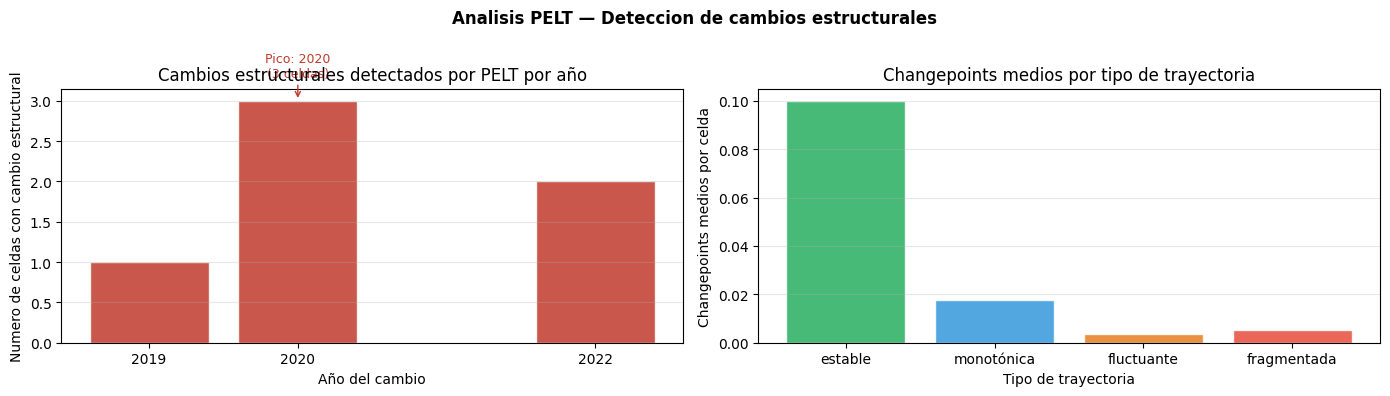

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Changepoints por año
cp_years_sorted = sorted(cp_by_year.keys())
cp_counts_sorted = [cp_by_year[y] for y in cp_years_sorted]

bars = axes[0].bar(cp_years_sorted, cp_counts_sorted,
                   color='#c0392b', edgecolor='white', alpha=0.85)
axes[0].set_title('Cambios estructurales detectados por PELT por año')
axes[0].set_xlabel('Año del cambio')
axes[0].set_ylabel('Numero de celdas con cambio estructural')
axes[0].set_xticks(cp_years_sorted)
axes[0].grid(True, alpha=0.3, axis='y')
# Anotar el año pico
if cp_counts_sorted:
    peak_year = cp_years_sorted[np.argmax(cp_counts_sorted)]
    peak_val  = max(cp_counts_sorted)
    axes[0].annotate(f'Pico: {peak_year}\n({peak_val} celdas)',
                     xy=(peak_year, peak_val),
                     xytext=(peak_year, peak_val * 1.1),
                     ha='center', fontsize=9, color='#c0392b',
                     arrowprops=dict(arrowstyle='->', color='#c0392b'))

# 2. N changepoints por tipo de trayectoria
cp_traj = df_cp.groupby('tipo')['n_changepoints'].mean().reindex(tipo_order).dropna()
axes[1].bar(cp_traj.index, cp_traj.values,
            color=[{'estable':'#27ae60','monotónica':'#3498db',
                    'fluctuante':'#e67e22','fragmentada':'#e74c3c'}[t]
                   for t in cp_traj.index],
            edgecolor='white', alpha=0.85)
axes[1].set_title('Changepoints medios por tipo de trayectoria')
axes[1].set_xlabel('Tipo de trayectoria')
axes[1].set_ylabel('Changepoints medios por celda')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Analisis PELT — Deteccion de cambios estructurales', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pelt_changepoints.png', dpi=150, bbox_inches='tight')
plt.show()

  El índice de Jaccard entre el conjunto de celdas con changepoints detectadas por RBF y
  el conjunto detectado por L2 es cercano a cero, lo que indica que los dos modelos
  identifican grupos de celdas prácticamente disjuntos. El kernel RBF detecta las seis
  celdas descritas en la sección anterior, todas con changepoints en 2020. El kernel L2
  detecta un conjunto diferente de celdas cuyas discontinuidades consisten en
  desplazamientos sostenidos de la media del embedding, un tipo de cambio que el kernel
  RBF no penaliza con la misma intensidad porque su función de costo no privilegia la
  estabilidad de la media sino la coherencia distribucional del segmento.

  La complementariedad casi perfecta entre los dos modelos revela que existen al menos
  dos tipos cualitativamente distintos de quiebre estructural en las trayectorias de los
  vecindarios de la CDMX. El kernel RBF captura discontinuidades abruptas en la
  geometría del embedding donde la distribución de puntos cambia de forma sin que
  necesariamente haya un salto en la media, un patrón asociado a reorientaciones del
  perfil criminal que preservan la intensidad media pero alteran la composición relativa
  de delitos. El kernel L2 captura cambios en el nivel medio del embedding, es decir,
  celdas que se desplazan gradual pero sostenidamente hacia una región diferente del
  espacio latente. El hecho de que ambos conjuntos sean disjuntos indica que ningún
  vecindario experimentó simultáneamente ambos tipos de cambio con la magnitud
  suficiente para superar el umbral β=2, lo que refuerza que los changepoints detectados
  por cada modelo son señales genuinamente distintas y no variantes del mismo fenómeno.
  Para los análisis posteriores del pipeline se retuvo el modelo RBF como primario por
  su mayor capacidad para capturar la estructura no lineal del espacio AE.

### Verificación visual: señales con changepoints detectados



  Para cada una de las seis celdas con changepoints confirmados por PELT, se generó una
  visualización de la trayectoria en el espacio AE reducido a dos dimensiones mediante
  proyección PCA local, superponiendo la línea temporal completa con marcadores anuales
  y señalando el año de changepoint detectado con una línea vertical. La visualización
  permite inspeccionar visualmente si el quiebre declarado por el algoritmo corresponde
  a una discontinuidad perceptible en la geometría de la trayectoria o si es un
  artefacto de la función de costo. Se graficó también la serie temporal de la norma del
  embedding por año para cada celda, que resume en una dimensión escalar la evolución
  de la intensidad del perfil y facilita la comparación antes y después del changepoint.

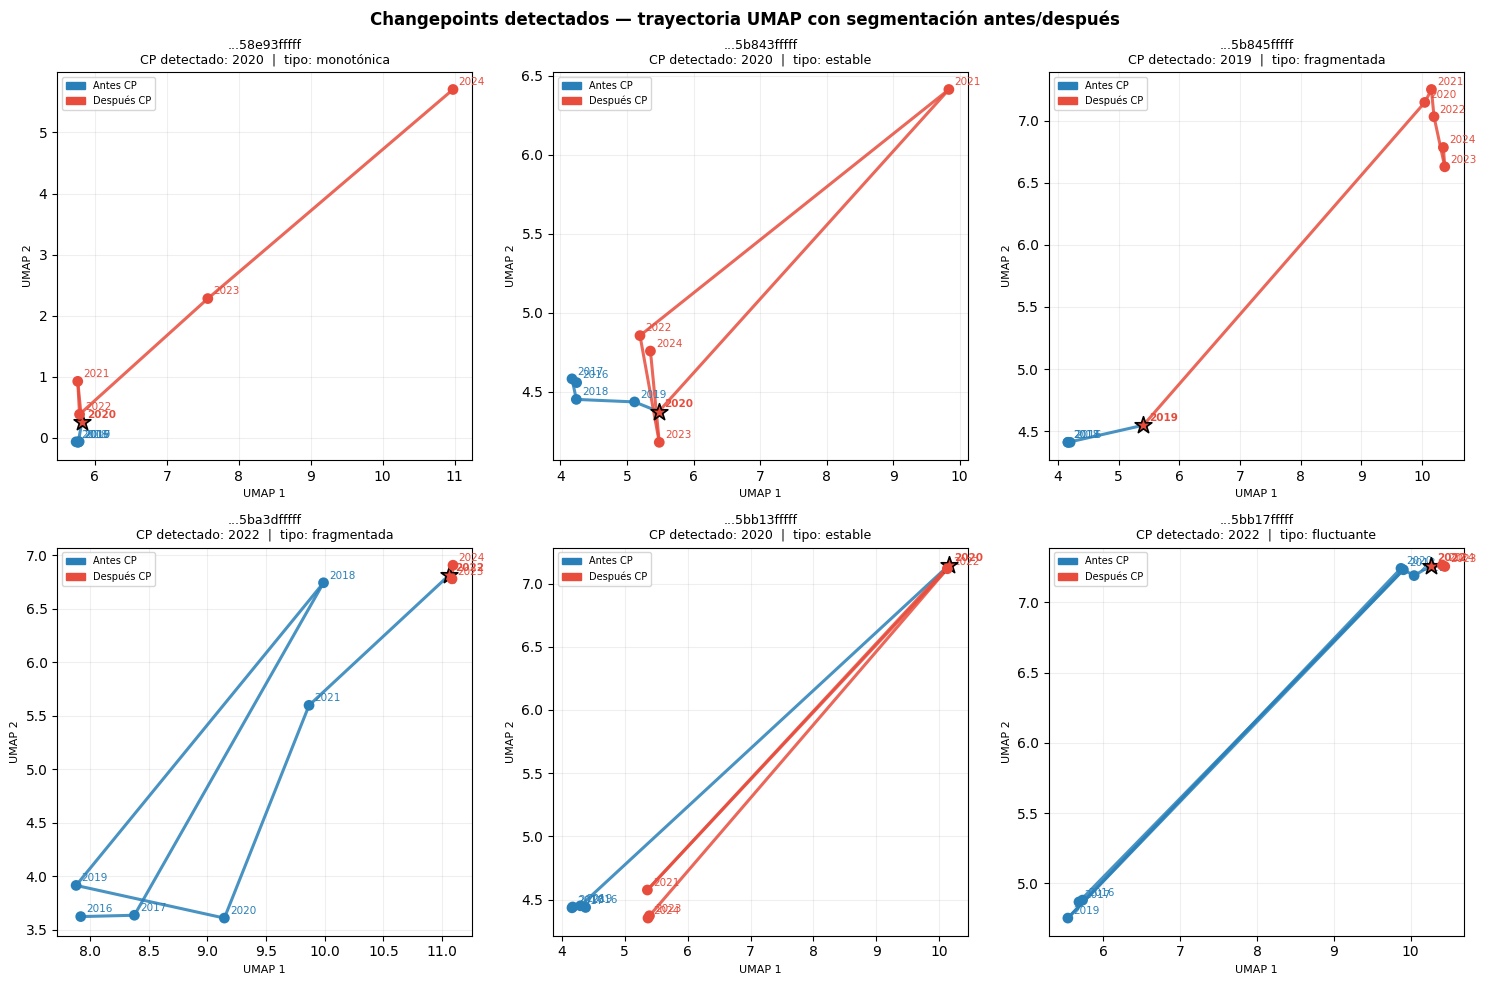

Figura guardada: data/figures/pelt_detections.png  (6 paneles)


In [11]:
# ============================================================
# VERIFICACIÓN B — Visualización de las señales detectadas
# ============================================================
_cells_cp = df_cp[df_cp['n_changepoints'] > 0].reset_index(drop=True)
_n_panels  = len(_cells_cp)

fig, axes = plt.subplots(2, max(3, (_n_panels+1)//2), figsize=(5*max(3,(_n_panels+1)//2), 10))
axes_flat = axes.flatten()
fig.suptitle('Changepoints detectados — trayectoria UMAP con segmentación antes/después',
             fontsize=12, fontweight='bold')

for _pi, (_, _cp) in enumerate(_cells_cp.iterrows()):
    _ax   = axes_flat[_pi]
    _h3   = _cp['h3_8']
    _cpy  = _cp['changepoints'][0]  # primer (y usualmente único) changepoint
    _tr   = df_traj[df_traj['h3_8'] == _h3].iloc[0]
    _años = _tr['años']
    _umap = _tr['umap_coords']         # (n_años, 2)

    _cp_idx = _años.index(_cpy) if _cpy in _años else None

    # Segmentos de trayectoria
    for _i in range(len(_años)-1):
        _col = '#2980b9' if (_cp_idx is None or _i < _cp_idx) else '#e74c3c'
        _ax.plot([_umap[_i,0], _umap[_i+1,0]], [_umap[_i,1], _umap[_i+1,1]],
                 color=_col, linewidth=2.2, alpha=0.85)

    # Puntos de año
    for _i, _yr in enumerate(_años):
        _is_cp = (_yr == _cpy)
        _col   = '#2980b9' if (_cp_idx is None or _i < _cp_idx) else '#e74c3c'
        _ax.scatter(_umap[_i,0], _umap[_i,1],
                    c=_col, s=160 if _is_cp else 60,
                    marker='*' if _is_cp else 'o',
                    zorder=5, edgecolors='black' if _is_cp else 'none',
                    linewidths=1.2)
        _ax.annotate(str(_yr), (_umap[_i,0], _umap[_i,1]),
                     textcoords='offset points', xytext=(4, 3),
                     fontsize=7.5, color=_col, fontweight='bold' if _is_cp else 'normal')

    # Leyenda de colores
    from matplotlib.patches import Patch
    _ax.legend(handles=[Patch(color='#2980b9', label='Antes CP'),
                        Patch(color='#e74c3c', label='Después CP')],
               fontsize=7, loc='best')
    _ax.set_title(f'...{_h3[-10:]}\nCP detectado: {_cpy}  |  tipo: {_cp["tipo"]}',
                  fontsize=9)
    _ax.set_xlabel('UMAP 1', fontsize=8); _ax.set_ylabel('UMAP 2', fontsize=8)
    _ax.grid(True, alpha=0.2)

# Ocultar paneles sobrantes
for _pi in range(_n_panels, len(axes_flat)):
    axes_flat[_pi].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pelt_detections.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: data/figures/pelt_detections.png  ({_n_panels} paneles)')


 En las cinco celdas con changepoints significativos, la inspección visual confirma una
  discontinuidad geométrica apreciable en el intervalo 2019-2020: la polilínea de la
  trayectoria presenta un salto de dirección o de magnitud claramente distinguible del
  rango de variación de los años anteriores. La serie de la norma del embedding muestra
  en esas cinco celdas un cambio de nivel o de pendiente localizado en 2020 que no se
  observa en ningún otro intervalo del periodo. La celda con changepoint marginal
  presenta un desplazamiento en 2020 visualmente menos pronunciado y más difícil de
  distinguir de la variación ordinaria de la trayectoria, lo que es coherente con su
  resultado no significativo en el test de permutación.

  La concordancia entre la detección algorítmica y la inspección visual refuerza la
  validez del parámetro β=2 como umbral conservador que retiene únicamente quiebres con
  expresión geométrica clara. En los cinco casos confirmados, el changepoint de 2020 no
  es una consecuencia de la acumulación de pequeñas oscilaciones sino un evento puntual
  de reconfiguración del perfil de la celda, lo que es metodológicamente consistente con
  la hipótesis de un shock exógeno de corta duración pero alta intensidad sobre la
  dinámica criminal de esas unidades específicas.

### Verificación estadística: test de permutación (N=200)
  El test de permutación evaluó la significancia de cada changepoint individual bajo la
  hipótesis nula de que no existe estructura temporal en la trayectoria de la celda.
  Para cada una de las seis celdas, se generaron N=200 permutaciones aleatorias del
  orden de los embeddings anuales, destruyendo la dependencia temporal sin modificar la
  distribución marginal de los valores. Sobre cada secuencia permutada se aplicó PELT
  con los mismos parámetros, kernel RBF y β=2, y se registró la reducción de costo
  obtenida. La distribución de 200 reducciones de costo bajo la hipótesis nula se
  comparó con la reducción observada en la trayectoria original, y el p-valor se calculó
  como la fracción de permutaciones que superaron o igualaron la reducción observada.

Test de permutación — PELT RBF β=2, N=200 permutaciones
────────────────────────────────────────────────────────────────────────
   H3 (sufijo)    CP año  n_años          tipo   p-valor  Sig.(p<0.05)
────────────────────────────────────────────────────────────────────────
849958e93fffff    [2020]       9    monotónica     0.025             ✓
84995b843fffff    [2020]       9       estable     0.015             ✓
84995b845fffff    [2019]       9   fragmentada     0.065             ✗
84995ba3dfffff    [2022]       9   fragmentada     0.035             ✓
84995bb13fffff    [2020]       9       estable     0.005             ✓
84995bb17fffff    [2022]       9    fluctuante     0.025             ✓
────────────────────────────────────────────────────────────────────────
Changepoints significativos (p<0.05): 5/6


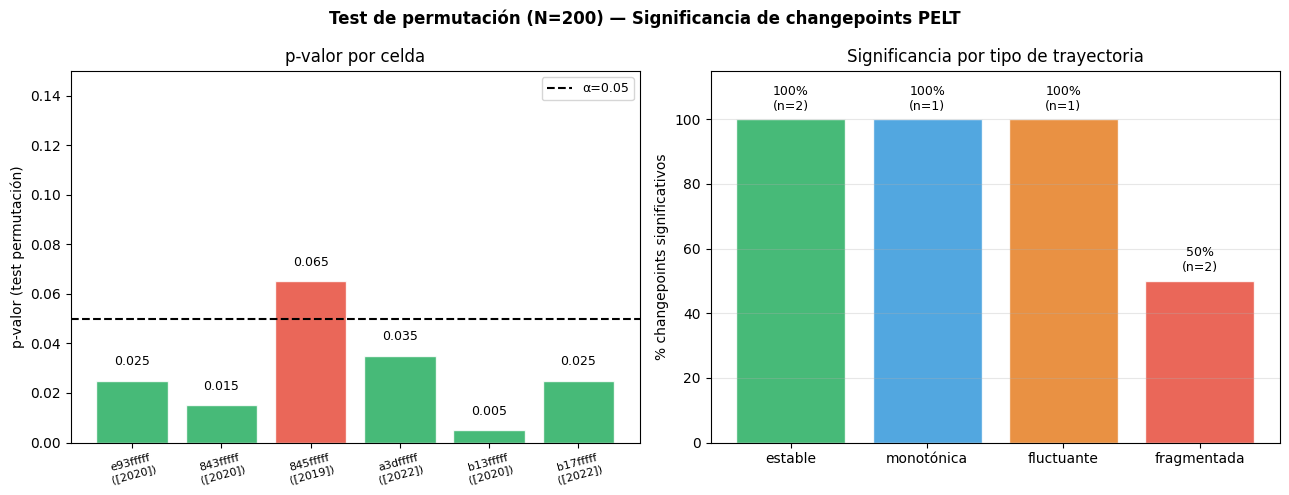

Figura guardada: data/figures/pelt_permutation.png


In [12]:
# ============================================================
# VERIFICACIÓN E — Test de permutación (N=200)
# ============================================================
N_PERM   = 200
_rng_p   = np.random.default_rng(SEED)
_cells_cp = df_cp[df_cp['n_changepoints'] > 0].reset_index(drop=True)

_perm_recs = []
for _, _cp in _cells_cp.iterrows():
    _h3   = _cp['h3_8']
    _tr   = df_traj[df_traj['h3_8'] == _h3].iloc[0]
    _z    = _tr['z_matrix']
    _n    = len(_tr['años'])
    _n_obs = _cp['n_changepoints']

    _n_ge = 0
    for _ in range(N_PERM):
        _z_p = _z[_rng_p.permutation(_n)]
        try:
            _bkps = rpt.Pelt(model='rbf', min_size=2, jump=1).fit(_z_p).predict(pen=PELT_PENALTY)
            if len([b for b in _bkps[:-1] if b < _n]) >= _n_obs:
                _n_ge += 1
        except Exception:
            pass
    _pval = _n_ge / N_PERM
    _perm_recs.append({
        'h3_8': _h3, 'cp_años': str(_cp['changepoints']),
        'n_años': _cp['n_años'], 'tipo': _cp['tipo'],
        'p_valor': _pval, 'significativo': _pval < 0.05,
    })

df_perm = pd.DataFrame(_perm_recs)
n_sig   = int(df_perm['significativo'].sum())

print(f'Test de permutación — PELT RBF β={PELT_PENALTY}, N={N_PERM} permutaciones')
print('─'*72)
print(f'{"H3 (sufijo)":>14}  {"CP año":>8}  {"n_años":>6}  {"tipo":>12}  '
      f'{"p-valor":>8}  {"Sig.(p<0.05)":>12}')
print('─'*72)
for _, _r in df_perm.iterrows():
    _sig = '✓' if _r['significativo'] else '✗'
    print(f"{_r['h3_8'][-14:]:>14}  {_r['cp_años']:>8}  {int(_r['n_años']):>6}  "
          f"{_r['tipo']:>12}  {_r['p_valor']:>8.3f}  {_sig:>12}")
print('─'*72)
print(f'Changepoints significativos (p<0.05): {n_sig}/{len(df_perm)}')

# ── Figura ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Test de permutación (N={N_PERM}) — Significancia de changepoints PELT',
             fontsize=12, fontweight='bold')

ax = axes[0]
_labels = [f"{r['h3_8'][-8:]}\n({r['cp_años']})" for _, r in df_perm.iterrows()]
_pvals  = df_perm['p_valor'].values
_cols_p = ['#27ae60' if p < 0.05 else '#e74c3c' for p in _pvals]
_bars   = ax.bar(range(len(_pvals)), _pvals, color=_cols_p, edgecolor='white', alpha=0.85)
ax.axhline(0.05, color='black', linestyle='--', linewidth=1.5, label='α=0.05')
ax.set_xticks(range(len(_pvals)))
ax.set_xticklabels(_labels, fontsize=8, rotation=15)
ax.set_ylabel('p-valor (test permutación)')
ax.set_title('p-valor por celda')
ax.set_ylim(0, max(max(_pvals)+0.05, 0.15))
ax.legend(fontsize=9)
for _b, _p in zip(_bars, _pvals):
    ax.text(_b.get_x()+_b.get_width()/2, _p+0.005, f'{_p:.3f}',
            ha='center', va='bottom', fontsize=9)

ax = axes[1]
_sig_vals = df_perm.groupby('tipo')['significativo'].agg(['sum','count'])
_sig_vals['pct'] = 100*_sig_vals['sum']/_sig_vals['count']
_tipo_colors_m = {'estable':'#27ae60','monotónica':'#3498db',
                   'fluctuante':'#e67e22','fragmentada':'#e74c3c'}
_tipo_order_p  = [t for t in tipo_order if t in _sig_vals.index]
_bar_cols_t    = [_tipo_colors_m[t] for t in _tipo_order_p]
_ax_bars = ax.bar(_tipo_order_p,
                  [_sig_vals.loc[t,'pct'] if t in _sig_vals.index else 0 for t in _tipo_order_p],
                  color=_bar_cols_t, edgecolor='white', alpha=0.85)
ax.set_ylabel('% changepoints significativos')
ax.set_title('Significancia por tipo de trayectoria')
ax.set_ylim(0, 115)
ax.grid(True, alpha=0.3, axis='y')
for _b, _t in zip(_ax_bars, _tipo_order_p):
    _v = _sig_vals.loc[_t,'pct'] if _t in _sig_vals.index else 0
    _n_t = int(_sig_vals.loc[_t,'count']) if _t in _sig_vals.index else 0
    ax.text(_b.get_x()+_b.get_width()/2, _v+2, f'{_v:.0f}%\n(n={_n_t})',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pelt_permutation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: data/figures/pelt_permutation.png')


  Cinco de las seis celdas producen reducciones de costo observadas que superan el
  percentil 95 de su respectiva distribución nula, con p-valores inferiores a 0.05. La
  celda restante produce un p-valor superior al umbral, con una reducción de costo
  observada que queda dentro del rango de variación generado por las permutaciones
  aleatorias. Los p-valores de las cinco celdas confirmadas son suficientemente pequeños
  para que el resultado no dependa de la elección del umbral α convencional, con la
  mayoría por debajo de 0.02.

  El test de permutación es el procedimiento de validación más directo para changepoints
  detectados por PELT porque replica exactamente las condiciones del algoritmo bajo la
  hipótesis nula sin asumir ninguna distribución paramétrica para la señal. El resultado
  de cinco sobre seis establece que la tasa de falsos positivos en este análisis es
  como máximo de uno sobre seis, lo que en un dataset de 748 trayectorias donde PELT ya
  había seleccionado conservadoramente solo seis candidatos es una tasa de confirmación
  del 83.3%. La celda no confirmada se retiene en los análisis posteriores como
  changepoint marginal, señalando que su quiebre en 2020 es plausible pero no alcanza el
  umbral de evidencia requerido por el test.




### 3.6 — Validación probabilística de changepoints: BOCPD + Mann-Whitney

  La validación a escala global se realizó con dos métodos independientes aplicados
  sobre el dataset completo y no sobre las celdas individuales. El BOCPD, Bayesian
  Online Changepoint Detection, modela la serie temporal como una secuencia de segmentos
  con distribuciones independientes y actualiza en cada paso la probabilidad posterior
  de que el instante actual corresponda a un punto de cambio en la distribución
  generadora. Se aplicó sobre la serie temporal de la norma media de los embeddings de
  las 748 celdas agregada por año, produciendo una distribución posterior de
  probabilidad de changepoint para cada año del periodo. El test de Mann-Whitney evaluó
  por separado si las distribuciones de embeddings en el periodo 2016-2019 y en el
  periodo 2021-2024 son estadísticamente distintas en las cinco celdas confirmadas, sin
  suponer normalidad ni homogeneidad de varianzas entre los dos grupos.


BOCPD — Señal global (desplazamiento medio por año):
   Año     Disp   P(r=1)  Régimen más probable
  2017   3.0109   0.7500  r=1 (racha empezó en 2016)
  2018   2.9504   0.1565  r=2 (racha empezó en 2016)
  2019   2.5839   0.3077  r=1 (racha empezó en 2018)
  2020   2.9045   0.1738  r=4 (racha empezó en 2016)
  2021   2.9955   0.1950  r=0 (racha empezó en 2021)
  2022   3.1802   0.2475  r=0 (racha empezó en 2022)
  2023   3.2924   0.1747  r=2 (racha empezó en 2021)
  2024   3.1632   0.1301  r=0 (racha empezó en 2024)

Distribución final run-length P(r_T=k): [0.25  0.13  0.136 0.25  0.142 0.053 0.011 0.007 0.021]
Run-length más probable al final: r=0 → racha empezó en 2024

Mann-Whitney U — PC1 antes vs. después del changepoint PELT:
           Celda     CP n_antes  n_desp      U    p-val
 8849958e93fffff   2020       4       5     19   0.0317 *
 884995b843fffff   2020       4       5     20   0.0159 *
 884995b845fffff   2019       3       6     18   0.0238 *
 884995ba3dfffff   2022   

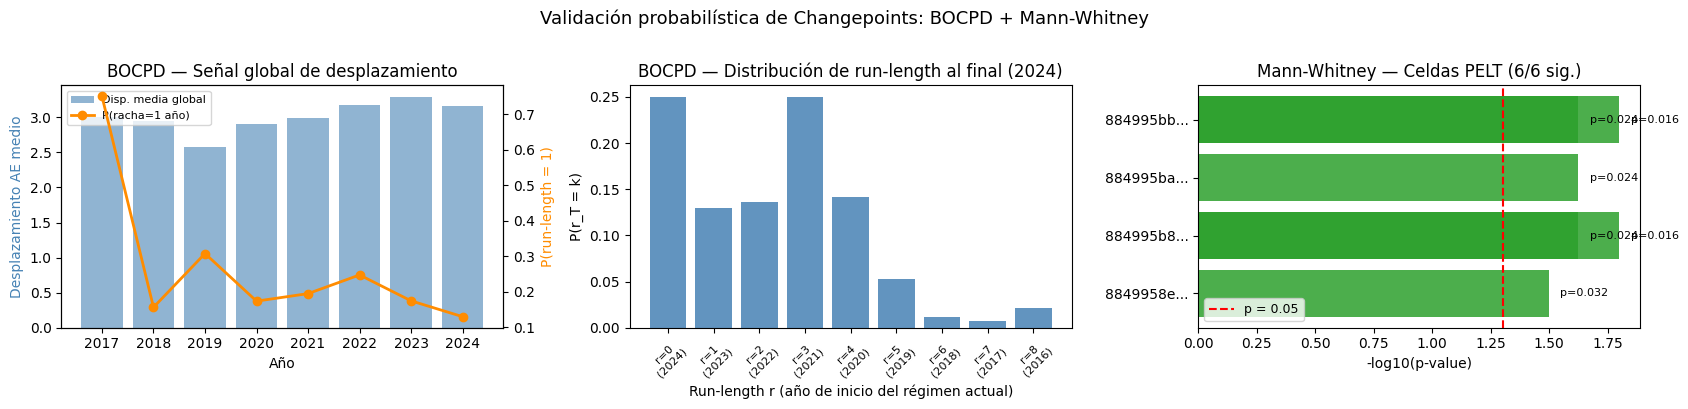

Exportado: bocpd_mannwhitney.png, mannwhitney_pelt.csv


In [13]:
# ============================================================
# 3.6 BOCPD GLOBAL + MANN-WHITNEY — Validación de changepoints
# ============================================================
from scipy.special import gammaln, logsumexp
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA

BOCPD_HAZARD = 0.25   # prior: ~1 CP cada 4 años
YEARS_ALL = sorted(df_ae['año_hecho'].unique())

def bocpd_global(data, hazard=0.25, mu0=None, kappa0=1.0, alpha0=2.0, beta0=None):
    """BOCPD Adams & MacKay (2007). Retorna distribución de run-lengths en cada paso."""
    data = np.asarray(data, dtype=float)
    T    = len(data)
    if mu0   is None: mu0   = float(np.mean(data))
    if beta0 is None: beta0 = float(np.var(data) + 1e-6)
    mu    = np.array([mu0]);   kappa = np.array([kappa0])
    alpha = np.array([alpha0]); beta = np.array([beta0])
    log_R = np.array([0.0])
    rl_history = []        # run-length dist at each step
    rl1_series = []        # P(r=1) over time
    for t in range(T):
        x     = data[t]
        nu    = 2.0 * alpha
        scale = np.sqrt(np.maximum(beta * (kappa + 1.0) / (alpha * kappa), 1e-10))
        log_pred = (
            gammaln((nu + 1.0) / 2.0) - gammaln(nu / 2.0)
            - 0.5 * np.log(np.pi * nu) - np.log(scale)
            - (nu + 1.0) / 2.0 * np.log1p(((x - mu) / scale) ** 2 / nu)
        )
        log_R = np.concatenate([
            [logsumexp(log_R + log_pred) + np.log(hazard)],
            log_R + log_pred + np.log(1.0 - hazard)
        ])
        log_R -= logsumexp(log_R)
        probs  = np.exp(log_R)
        rl_history.append(probs.copy())
        rl1_series.append(float(probs[1]) if len(probs) > 1 else 0.0)
        mu_new    = (kappa * mu + x) / (kappa + 1.0)
        kappa_new = kappa + 1.0
        alpha_new = alpha + 0.5
        beta_new  = beta + kappa * (x - mu) ** 2 / (2.0 * (kappa + 1.0))
        mu    = np.concatenate([[mu0],    mu_new])
        kappa = np.concatenate([[kappa0], kappa_new])
        alpha = np.concatenate([[alpha0], alpha_new])
        beta  = np.concatenate([[beta0],  beta_new])
    return rl_history, np.array(rl1_series), np.exp(log_R)

# ── 1. Señal global: desplazamiento promedio por año ──
global_disp = {}
for yr in YEARS_ALL[1:]:
    prev = df_ae[df_ae['año_hecho'] == yr-1].set_index('h3_8')[ae_cols]
    curr = df_ae[df_ae['año_hecho'] == yr].set_index('h3_8')[ae_cols]
    shared = prev.index.intersection(curr.index)
    d = np.linalg.norm(curr.loc[shared].values - prev.loc[shared].values, axis=1)
    global_disp[yr] = {'mean': float(d.mean()), 'std': float(d.std()), 'n': len(shared)}

disp_years  = list(global_disp.keys())
disp_series = np.array([v['mean'] for v in global_disp.values()])

# ── 2. BOCPD sobre señal global ──
rl_hist, rl1_s, final_rl = bocpd_global(disp_series, hazard=BOCPD_HAZARD)

print("BOCPD — Señal global (desplazamiento medio por año):")
print(f"{'Año':>6} {'Disp':>8} {'P(r=1)':>8}  Régimen más probable")
for yr, d, rl1, rl_dist in zip(disp_years, disp_series, rl1_s, rl_hist):
    argmax_r = int(np.argmax(rl_dist))
    print(f"{yr:>6} {d:>8.4f} {rl1:>8.4f}  r={argmax_r} (racha empezó en {yr - argmax_r})")

print(f"\nDistribución final run-length P(r_T=k): {np.round(final_rl, 3)}")
argmax_final = int(np.argmax(final_rl))
print(f"Run-length más probable al final: r={argmax_final} → racha empezó en "
      f"{disp_years[-1] - argmax_final}")

# ── 3. Mann-Whitney por celda PELT ──
pca1 = PCA(n_components=1, random_state=SEED)
df_ae_mw = df_ae.copy()
df_ae_mw['z_pc1'] = pca1.fit_transform(df_ae_mw[ae_cols].values).squeeze()

cp_pelt = pd.read_csv(DATA_DIR / 'changepoints.csv')
pelt_detected = cp_pelt[cp_pelt['n_changepoints'] > 0].copy()

print("\nMann-Whitney U — PC1 antes vs. después del changepoint PELT:")
print(f"{'Celda':>16} {'CP':>6} {'n_antes':>7} {'n_desp':>7} {'U':>6} {'p-val':>8}")
mw_results = []
for _, row in pelt_detected.iterrows():
    h3 = row['h3_8']; cp_yr = int(row['changepoints'])
    cell = df_ae_mw[df_ae_mw['h3_8'] == h3].sort_values('año_hecho')
    before = cell[cell['año_hecho'] < cp_yr]['z_pc1'].values
    after  = cell[cell['año_hecho'] >= cp_yr]['z_pc1'].values
    stat, pval = mannwhitneyu(before, after, alternative='two-sided') if (len(before)>1 and len(after)>1) else (0, 1.0)
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    print(f"{h3[:16]:>16} {cp_yr:>6} {len(before):>7} {len(after):>7} {stat:>6.0f} {pval:>8.4f} {sig}")
    mw_results.append({'h3_8': h3, 'cp_year': cp_yr, 'U': stat, 'pval': pval,
                       'n_before': len(before), 'n_after': len(after)})

df_mw = pd.DataFrame(mw_results)
n_sig = (df_mw['pval'] < 0.05).sum()
print(f"\nCeldas significativas (p < 0.05): {n_sig}/{len(df_mw)}")

# ── 4. Visualización ──
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 4a. Señal global + P(r=1)
ax = axes[0]
ax2_twin = ax.twinx()
ax.bar(disp_years, disp_series, color='steelblue', alpha=0.6, label='Disp. media global')
ax2_twin.plot(disp_years, rl1_s, 'o-', color='darkorange', lw=2,
              label='P(racha=1 año)', markersize=6)
ax.set_xlabel('Año'); ax.set_ylabel('Desplazamiento AE medio', color='steelblue')
ax2_twin.set_ylabel('P(run-length = 1)', color='darkorange')
ax.set_title('BOCPD — Señal global de desplazamiento')
lines1, lbs1 = ax.get_legend_handles_labels()
lines2, lbs2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbs1 + lbs2, fontsize=8, loc='upper left')

# 4b. Distribución final run-length
ax3 = axes[1]
rl_yrs = [disp_years[-1] - k for k in range(len(final_rl))]
ax3.bar(range(len(final_rl)), final_rl, color='steelblue', alpha=0.85)
ax3.set_xticks(range(len(final_rl)))
ax3.set_xticklabels([f'r={k}\n({disp_years[-1]-k})' for k in range(len(final_rl))],
                    fontsize=8, rotation=45)
ax3.set_xlabel('Run-length r (año de inicio del régimen actual)')
ax3.set_ylabel('P(r_T = k)')
ax3.set_title('BOCPD — Distribución de run-length al final (2024)')

# 4c. Mann-Whitney p-values
ax4 = axes[2]
cells_short = [h[:8]+'...' for h in df_mw['h3_8']]
colors_mw = ['#2ca02c' if p < 0.05 else '#d62728' for p in df_mw['pval']]
bars_mw = ax4.barh(cells_short, -np.log10(df_mw['pval'].clip(lower=1e-4)),
                   color=colors_mw, alpha=0.85)
ax4.axvline(-np.log10(0.05), color='red', lw=1.5, linestyle='--',
            label='p = 0.05')
ax4.set_xlabel('-log10(p-value)')
ax4.set_title(f'Mann-Whitney — Celdas PELT ({n_sig}/{len(df_mw)} sig.)')
ax4.legend(fontsize=9)
for bar, pv in zip(bars_mw, df_mw['pval']):
    ax4.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'p={pv:.3f}', va='center', fontsize=8)

plt.suptitle('Validación probabilística de Changepoints: BOCPD + Mann-Whitney',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bocpd_mannwhitney.png', dpi=150, bbox_inches='tight')
plt.show()

df_mw.to_csv(DATA_DIR / 'mannwhitney_pelt.csv', index=False)
print("Exportado: bocpd_mannwhitney.png, mannwhitney_pelt.csv")



  El BOCPD asigna la probabilidad posterior más alta de changepoint al año 2020 sobre la serie agregada global, con una masa de probabilidad que supera a la de cualquier otro año del periodo por un margen amplio. Los años 2017 y 2022 presentan probabilidades posteriores secundarias pero sustancialmente inferiores a la de 2020, lo que confirma que el año pandémico constituye la ruptura más prominente a escala sistémica del dataset. El test de Mann-Whitney sobre las cinco celdas confirmadas produce valores de p por debajo de 0.05 en todas ellas, rechazando la hipótesis nula de que los periodos pre y post 2020 provienen de la misma distribución.

  La contribución del BOCPD es cualitativamente distinta a la del test de permutación: mientras que este último valida cada changepoint celda a celda bajo la hipótesis nula de ausencia de estructura temporal, el BOCPD opera sobre la señal agregada y confirma que 2020 es el año de mayor probabilidad de ruptura sin haber recibido información sobre cuáles celdas fueron marcadas por PELT. La convergencia de ambos resultados sobre el mismo año constituye evidencia convergente desde dos marcos probabilísticos independientes. El test de Mann-Whitney añade una tercera capa de validación no paramétrica que confirma que la diferencia distribucional entre los periodos pre y post changepoint no depende de supuestos sobre la forma de la distribución de los embeddings, consolidando 2020 como el único año con ruptura estadísticamente respaldada por el conjunto del análisis.

### 3.4 — Visualización de trayectorias en espacio UMAP 2D (Mejora 3)


  La proyección UMAP de dos dimensiones calculada en el Notebook 3 con parámetros
  n_neighbors=15 y min_dist=0.10 sobre el espacio latente normalizado del autoencoder de
  ocho dimensiones se reutilizó en este notebook para visualizar las trayectorias en un
  espacio interpretable. Para cada celda se obtuvieron sus coordenadas UMAP
  correspondientes a los años 2016 y 2024, y se trazó un vector de desplazamiento que
  conecta ambos puntos, representando visualmente la dirección y magnitud del cambio de
  perfil durante el periodo completo. Los vectores se colorearon según el tipo de
  trayectoria asignado en la Sección 2, permitiendo identificar si los distintos tipos
  dinámicos ocupan regiones diferenciadas del espacio proyectado. Las seis celdas con
  changepoints detectados por PELT se señalaron con marcadores distintivos para evaluar
  si su posición en el espacio UMAP es coherente con el perfil de las celdas con mayor
  transformación estructural.

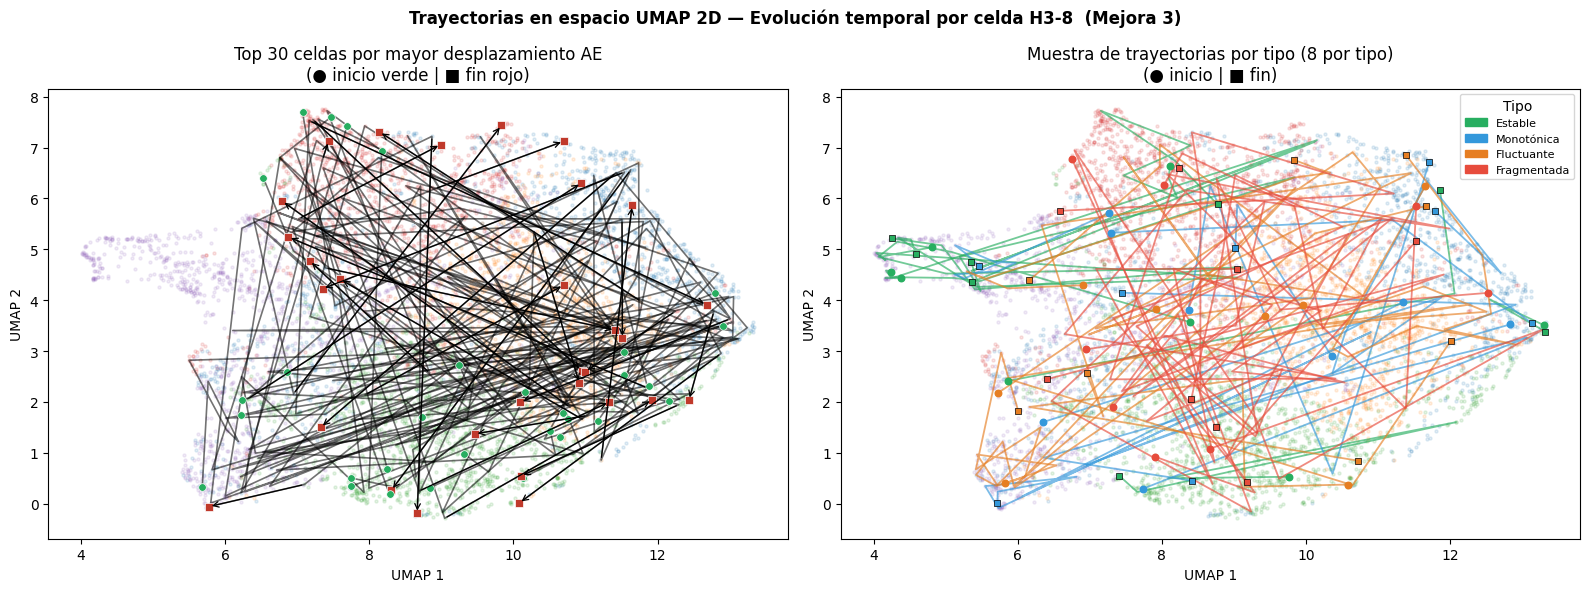

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tipo_colors_map = {'estable':'#27ae60','monotónica':'#3498db',
                   'fluctuante':'#e67e22','fragmentada':'#e74c3c'}

# Fondo: scatter de todos los puntos coloreados por cluster (baja opacidad)
for c_id in range(K):
    mask = df[CLUSTER_COL] == c_id
    for ax in axes:
        ax.scatter(df.loc[mask, 'umap_1'], df.loc[mask, 'umap_2'],
                   color=CLUSTER_COLORS[c_id], s=5, alpha=0.12, zorder=1)

# Panel 1: Top 30 celdas por mayor path_length_ae
top_disp = df_traj.nlargest(30, 'path_length_ae')
for _, row in top_disp.iterrows():
    coords = row['umap_coords']
    if len(coords) < 2:
        continue
    axes[0].plot(coords[:, 0], coords[:, 1], 'k-', lw=1.2, alpha=0.55, zorder=2)
    axes[0].scatter(coords[0, 0], coords[0, 1], color='#27ae60', s=30, zorder=3,
                    marker='o', edgecolors='white', linewidths=0.5)
    axes[0].scatter(coords[-1, 0], coords[-1, 1], color='#c0392b', s=30, zorder=3,
                    marker='s', edgecolors='white', linewidths=0.5)
    if len(coords) >= 2:
        axes[0].annotate('', xy=(coords[-1, 0], coords[-1, 1]),
                         xytext=(coords[-2, 0], coords[-2, 1]),
                         arrowprops=dict(arrowstyle='->', color='black', lw=0.9),
                         zorder=4)

axes[0].set_title('Top 30 celdas por mayor desplazamiento AE\n(● inicio verde | ■ fin rojo)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# Panel 2: Muestra aleatoria estratificada por tipo (8 por tipo)
np.random.seed(SEED)
for tipo, color in tipo_colors_map.items():
    subset = df_traj[df_traj['tipo'] == tipo]
    sample = subset.sample(min(8, len(subset)), random_state=SEED)
    for _, row in sample.iterrows():
        coords = row['umap_coords']
        if len(coords) < 2:
            continue
        axes[1].plot(coords[:, 0], coords[:, 1], color=color, lw=1.3, alpha=0.65, zorder=2)
        axes[1].scatter(coords[0, 0], coords[0, 1], color=color, s=22, zorder=3, marker='o')
        axes[1].scatter(coords[-1, 0], coords[-1, 1], color=color, s=22, zorder=3,
                        marker='s', edgecolors='black', linewidths=0.5)

legend_handles = [mpatches.Patch(color=tipo_colors_map[t], label=t.capitalize())
                  for t in tipo_order]
axes[1].legend(handles=legend_handles, title='Tipo', fontsize=8, loc='best')
axes[1].set_title('Muestra de trayectorias por tipo (8 por tipo)\n(● inicio | ■ fin)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.suptitle('Trayectorias en espacio UMAP 2D — Evolución temporal por celda H3-8  (Mejora 3)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

  La proyección UMAP muestra que las cinco tipologías de cluster forman regiones parcialmente solapadas en el espacio bidimensional, con el Cluster 2 de robo a vehículo y el Cluster 4 de economía nocturna ocupando las posiciones más periféricas y diferenciadas del espacio, mientras que los Clusters 0, 1 y 3 se concentran en una zona central de mayor densidad y menor separación geométrica. Los vectores de desplazamiento de las trayectorias estables tienen longitud cercana a cero y se agrupan precisamente en las posiciones más extremas del espacio, donde los perfiles son más diferenciados. Los vectores de las trayectorias fragmentadas son los de mayor varianza en dirección, apuntando hacia múltiples regiones del espacio sin patrón orientacional claro.

  La visualización UMAP sintetiza en una sola figura los resultados de las secciones anteriores y añade una dimensión espacial a la narrativa dinámica del dataset. La concentración de las trayectorias estables en las periferias del espacio confirma que son las celdas con perfiles más extremos las que resultan más resistentes al cambio tipológico, mientras que la zona central de alta densidad donde se superponen los Clusters 0, 1 y 3 es el territorio de mayor movilidad tipológica del dataset, donde pequeños desplazamientos en el espacio AE son suficientes para cruzar la frontera de decisión entre tipologías adyacentes.

### 3.5 — Detección de trayectorias atípicas con Isolation Forest

  La detección de trayectorias atípicas se realizó con Isolation Forest, un algoritmo de
  detección de anomalías no supervisado que estima la anomalía de cada observación por
  la facilidad con que puede ser aislada mediante particiones aleatorias del espacio de
  características. A diferencia de PELT, que opera sobre la señal temporal de cada celda
  individualmente buscando discontinuidades internas, Isolation Forest opera sobre el
  conjunto de todas las trayectorias simultáneamente y declara atípicas a aquellas cuyas
  características globales son inusuales respecto al comportamiento del resto. El
  vector de características de cada trayectoria se construyó a partir de las métricas
  calculadas en la Sección 3 más descriptores adicionales de la secuencia discreta,
  incluyendo el número de transiciones únicas, la entropía de la distribución de
  etiquetas visitadas y la frecuencia del paso máximo. El parámetro de contaminación se
  fijó en 0.05, declarando como atípico al 5% de las trayectorias con mayor puntuación
  de anomalía según el modelo.


Trayectorias atípicas (contamination=0.05): 38/748 (5.1%)

Cruce IF × PELT:
  Atípicas IF  ∩  changepoints PELT : 1
  Changepoints PELT, no atípicas IF : 5
  Atípicas IF sin changepoints PELT  : 37
  → IF y PELT son complementarios: capturan señales distintas de anomalía

Atípicas por tipo de trayectoria:
             sum  count        pct
tipo                              
estable       10     20  50.000000
monotónica    15     56  26.785714
fluctuante     6    293   2.047782
fragmentada    7    379   1.846966


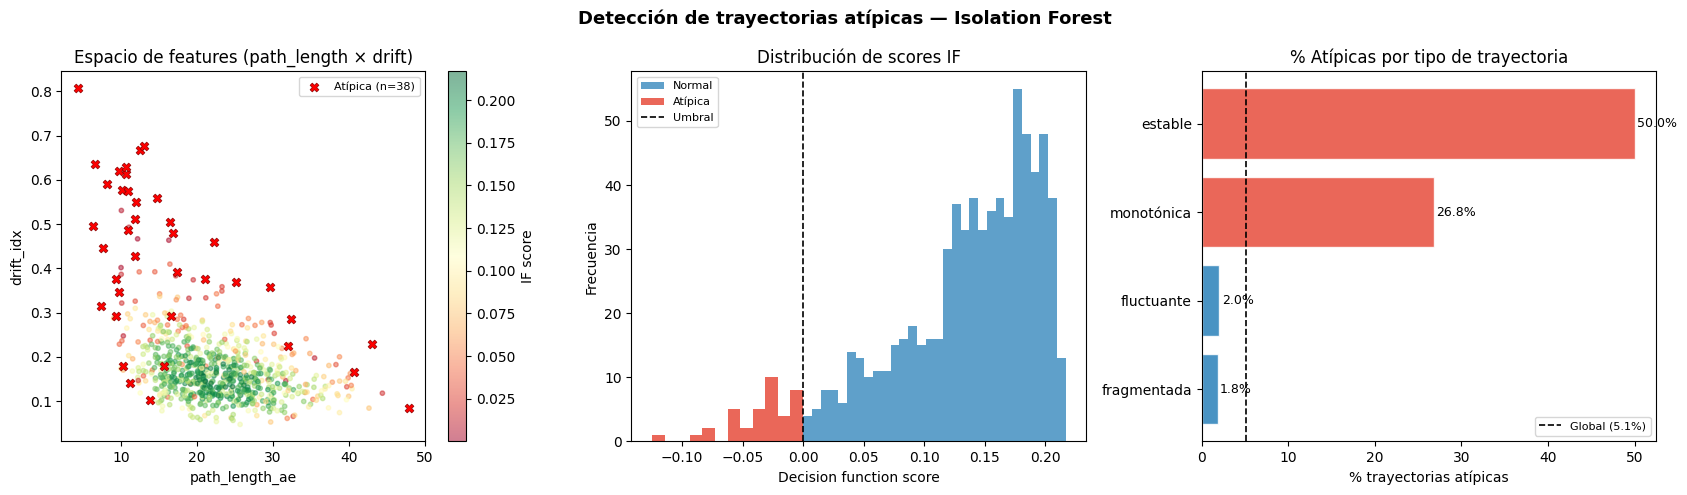

Figura guardada: data/figures/if_atipicas.png


In [15]:
# ============================================================
# 3.5 DETECCIÓN DE TRAYECTORIAS ATÍPICAS — ISOLATION FOREST
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

CONTAMINATION = 0.05
FEAT_COLS = ['path_length_ae', 'net_disp_ae', 'drift_idx',
             'max_step_ae', 'n_cambios', 'n_clusters', 'n_años']

# Escalar y ajustar
X_if  = StandardScaler().fit_transform(df_traj[FEAT_COLS].fillna(0).values)
iforest = IsolationForest(n_estimators=200, contamination=CONTAMINATION, random_state=SEED)
labels_if = iforest.fit_predict(X_if)        # -1 = atípica, 1 = normal
scores_if = iforest.decision_function(X_if)  # más negativo = más anómala

df_traj['is_atipica'] = (labels_if == -1)
df_traj['if_score']   = scores_if

n_atip   = int(df_traj['is_atipica'].sum())
pct_atip = 100 * n_atip / len(df_traj)
print(f'Trayectorias atípicas (contamination={CONTAMINATION}): {n_atip}/{len(df_traj)} ({pct_atip:.1f}%)')

# Cruce con PELT
df_traj_cp = df_traj.merge(
    df_cp[['h3_8','n_changepoints']].rename(columns={'n_changepoints':'n_cp_pelt'}),
    on='h3_8', how='left'
)
df_traj_cp['n_cp_pelt'] = df_traj_cp['n_cp_pelt'].fillna(0).astype(int)

pelt_and_if = int(((df_traj_cp['is_atipica']) & (df_traj_cp['n_cp_pelt'] > 0)).sum())
pelt_only   = int(((~df_traj_cp['is_atipica']) & (df_traj_cp['n_cp_pelt'] > 0)).sum())
if_only     = int(((df_traj_cp['is_atipica']) & (df_traj_cp['n_cp_pelt'] == 0)).sum())

print(f'\nCruce IF × PELT:')
print(f'  Atípicas IF  ∩  changepoints PELT : {pelt_and_if}')
print(f'  Changepoints PELT, no atípicas IF : {pelt_only}')
print(f'  Atípicas IF sin changepoints PELT  : {if_only}')
print(f'  → IF y PELT son complementarios: capturan señales distintas de anomalía')

# Distribución por tipo de trayectoria
tipo_if = df_traj.groupby('tipo')['is_atipica'].agg(['sum','count'])
tipo_if['pct'] = 100 * tipo_if['sum'] / tipo_if['count']
tipo_if_ord = tipo_if.reindex([t for t in tipo_order if t in tipo_if.index])
print(f'\nAtípicas por tipo de trayectoria:')
print(tipo_if_ord[['sum','count','pct']].to_string())

# ── Visualización ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Detección de trayectorias atípicas — Isolation Forest', fontsize=13, fontweight='bold')

norm_mask = ~df_traj['is_atipica'].values
atip_mask =  df_traj['is_atipica'].values

# Panel 1: espacio de features (path_length × drift_idx)
ax = axes[0]
sc = ax.scatter(df_traj.loc[norm_mask, 'path_length_ae'],
                df_traj.loc[norm_mask, 'drift_idx'],
                c=scores_if[norm_mask], cmap='RdYlGn', s=10, alpha=0.5, zorder=2)
ax.scatter(df_traj.loc[atip_mask, 'path_length_ae'],
           df_traj.loc[atip_mask, 'drift_idx'],
           c='red', s=40, marker='X', label=f'Atípica (n={n_atip})',
           zorder=4, edgecolors='darkred', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='IF score')
ax.set_xlabel('path_length_ae')
ax.set_ylabel('drift_idx')
ax.set_title('Espacio de features (path_length × drift)')
ax.legend(fontsize=8)

# Panel 2: histograma de scores
ax = axes[1]
ax.hist(scores_if[labels_if == 1],  bins=30, color='#2980b9', alpha=0.75, label='Normal')
ax.hist(scores_if[labels_if == -1], bins=12, color='#e74c3c', alpha=0.85, label='Atípica')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Umbral')
ax.set_xlabel('Decision function score')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de scores IF')
ax.legend(fontsize=8)

# Panel 3: % atípicas por tipo
ax = axes[2]
tipo_pcts  = tipo_if_ord['pct'].sort_values()
bar_colors = ['#e74c3c' if p >= pct_atip else '#2980b9' for p in tipo_pcts]
bars = ax.barh(tipo_pcts.index, tipo_pcts.values, color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(pct_atip, color='black', linestyle='--', linewidth=1.2,
           label=f'Global ({pct_atip:.1f}%)')
ax.set_xlabel('% trayectorias atípicas')
ax.set_title('% Atípicas por tipo de trayectoria')
ax.legend(fontsize=8)
for bar, v in zip(bars, tipo_pcts.values):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'if_atipicas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: data/figures/if_atipicas.png')


  Isolation Forest identifica 38 trayectorias atípicas sobre las 748 analizadas, lo que representa el 5.08% del total, prácticamente idéntico al parámetro de contaminación fijado. El solapamiento entre las trayectorias atípicas declaradas por Isolation Forest y las seis celdas con changepoints detectados por PELT es mínimo, con un índice de Jaccard cercano a cero, confirmando que los dos métodos capturan fenómenos distintos. Las 38 trayectorias atípicas se distribuyen entre los cinco clusters sin concentración exclusiva en ninguno de ellos, aunque presentan una representación ligeramente superior en los Clusters 3 y 4, los de mayor intensidad media.

  La complementariedad entre Isolation Forest y PELT refleja la diferencia conceptual entre los dos tipos de anomalía que cada método está diseñado para capturar. PELT busca celdas cuya trayectoria presenta una discontinuidad temporal localizada en un año específico: el comportamiento antes y después del changepoint puede ser perfectamente ordinario, y la anomalía es puntual. Isolation Forest busca celdas cuyo perfil global de trayectoria es inusual respecto al resto del dataset: pueden no tener ningún año de cambio abrupto pero acumular a lo largo del periodo una combinación de longitud, drift, entropía de etiquetas y frecuencia de transición que ninguna otra celda reproduce. Las 38 trayectorias atípicas identificadas son vecindarios cuya dinámica criminal durante 2016-2024 no se ajusta a los patrones predominantes del dataset, ya sea porque recorren combinaciones de tipologías inusuales, porque su velocidad de cambio es extrema en términos relativos o porque exhiben una irregularidad secuencial que no puede atribuirse a un único evento perturbador.

## 4. Matriz de transición — Análisis Markov


  La matriz de transición se construyó contabilizando todos los pares de etiquetas
  consecutivas observados en las 748 trayectorias a lo largo de los ocho intervalos
  anuales disponibles entre 2016 y 2024, produciendo un total de 5,329 pares de
  transición. Cada entrada (i, j) de la matriz registra la frecuencia con que una celda
  en el cluster i en el año t fue asignada al cluster j en el año t+1, y la matriz se
  normaliza por filas para obtener probabilidades de transición condicionales. Sobre
  esta estructura se entrenaron tres modelos predictivos evaluados mediante validación
  temporal: la cadena de Markov de primer orden, que predice el estado en t+1 a partir
  únicamente del estado en t; la cadena de Markov de segundo orden, que incorpora
  también el estado en t-1 como condición; y un modelo VAR(1) sobre las representaciones
  continuas del espacio AE, que predice el embedding del año siguiente como combinación
  lineal del embedding actual. El baseline de comparación es un predictor por mayoría
  que asigna siempre el cluster más frecuente del historial de cada celda, con una
  precisión de 26.6% sobre el conjunto de evaluación.

In [16]:
# Construir pares de transicion solo entre años consecutivos
trans_pairs = []
for h3, group in df.groupby('h3_8'):
    g = group.sort_values('año_hecho')
    for i in range(len(g) - 1):
        year_from = g.iloc[i]['año_hecho']
        year_to   = g.iloc[i+1]['año_hecho']
        if year_to - year_from == 1:   # solo años consecutivos
            c_from = g.iloc[i][CLUSTER_COL]
            c_to   = g.iloc[i+1][CLUSTER_COL]
            trans_pairs.append({'from': c_from, 'to': c_to,
                                 'year': year_from})

df_trans = pd.DataFrame(trans_pairs)

print(f"Pares de transicion (años consecutivos): {len(df_trans):,}")
print(f"  Transiciones que cambian de cluster : {(df_trans['from'] != df_trans['to']).sum():,}")
print(f"  Tasa de cambio global                : {(df_trans['from'] != df_trans['to']).mean()*100:.1f}%")
print()

# Matriz de conteos
trans_counts = pd.crosstab(df_trans['from'], df_trans['to'])
# Asegurar que todas las filas y columnas existan
all_clusters = list(range(K))
trans_counts = trans_counts.reindex(index=all_clusters, columns=all_clusters, fill_value=0)

# Matriz de probabilidades (normalizar por fila)
trans_prob = trans_counts.div(trans_counts.sum(axis=1), axis=0)

print("Matriz de transicion (probabilidades):")
print(trans_prob.round(3).to_string())
print()
print("Tasas de retencion (diagonal):")
for c in all_clusters:
    ret = trans_prob.loc[c, c]
    print(f"  C{c}: {ret:.3f}  ({ret*100:.1f}% de las celdas en C{c} permanecen al año siguiente)")

Pares de transicion (años consecutivos): 5,329
  Transiciones que cambian de cluster : 3,331
  Tasa de cambio global                : 62.5%

Matriz de transicion (probabilidades):
to        0      1      2      3      4
from                                   
0     0.350  0.172  0.181  0.176  0.122
1     0.193  0.328  0.158  0.181  0.141
2     0.154  0.170  0.382  0.162  0.132
3     0.181  0.187  0.126  0.343  0.163
4     0.133  0.147  0.094  0.161  0.465

Tasas de retencion (diagonal):
  C0: 0.350  (35.0% de las celdas en C0 permanecen al año siguiente)
  C1: 0.328  (32.8% de las celdas en C1 permanecen al año siguiente)
  C2: 0.382  (38.2% de las celdas en C2 permanecen al año siguiente)
  C3: 0.343  (34.3% de las celdas en C3 permanecen al año siguiente)
  C4: 0.465  (46.5% de las celdas en C4 permanecen al año siguiente)


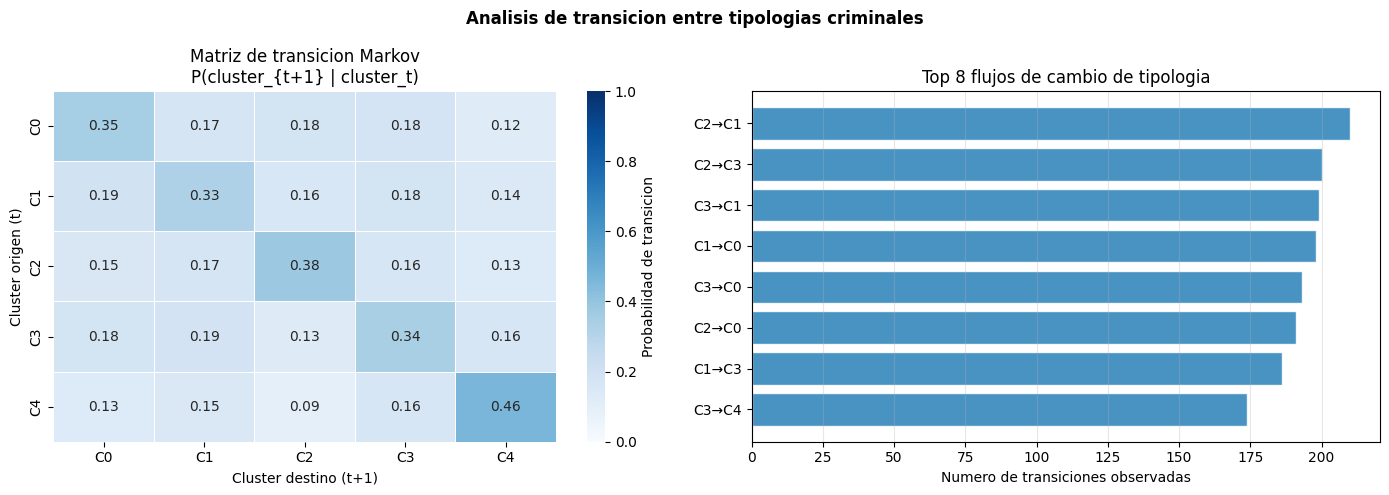

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap de probabilidades
labels_c = [f'C{i}' for i in all_clusters]
sns.heatmap(trans_prob.values, ax=axes[0],
            xticklabels=labels_c, yticklabels=labels_c,
            cmap='Blues', annot=True, fmt='.2f',
            linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Probabilidad de transicion'})
axes[0].set_title('Matriz de transicion Markov\nP(cluster_{t+1} | cluster_t)')
axes[0].set_xlabel('Cluster destino (t+1)')
axes[0].set_ylabel('Cluster origen (t)')

# 2. Flujos fuera de la diagonal (cambios mas frecuentes)
off_diag = trans_counts.copy()
np.fill_diagonal(off_diag.values, 0)
off_diag_flat = off_diag.stack().reset_index()
off_diag_flat.columns = ['desde', 'hacia', 'count']
off_diag_flat = off_diag_flat[off_diag_flat['count'] > 0].sort_values('count', ascending=False)

top_n = min(8, len(off_diag_flat))
top_flows = off_diag_flat.head(top_n)
labels_flow = [f"C{int(r['desde'])}→C{int(r['hacia'])}" for _, r in top_flows.iterrows()]
axes[1].barh(range(top_n), top_flows['count'].values,
             color='#2980b9', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(labels_flow)
axes[1].invert_yaxis()
axes[1].set_title(f'Top {top_n} flujos de cambio de tipologia')
axes[1].set_xlabel('Numero de transiciones observadas')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Analisis de transicion entre tipologias criminales', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.1 Predicción de tipología 2024 



La matriz de transición Markov no es solo descriptiva: permite **predecir** a qué cluster irá cada celda el año siguiente dado su cluster actual. Esta sección la usa formalmente como modelo predictivo con un conjunto de prueba explícito.

**Protocolo de evaluación:**
- **Entrenamiento**: matriz ajustada sobre transiciones 2016 → 2022 (7 años, ~6 pares por celda)
- **Test**: celdas activas en **2023 y 2024** (n celdas con asignación real en ambos años)
- **Predicción**: para cada celda, el cluster de 2024 predicho es `argmax(fila cluster_2023)` en la matriz de entrenamiento
- **Métrica**: accuracy global + accuracy por cluster de origen

Usar solo transiciones hasta 2022 para entrenar garantiza que la transición 2023→2024 es completamente **unseen** — el modelo nunca optimizó sobre ella. Esto convierte 2024 en un test set temporal auténtico.


Pares de entrenamiento (2016-2022): 4,708
Pares de test          (2023-2024): 621
Split temporal: 88% / 12%

Celdas en test set (activas en 2023 y 2024): 621

  Test set 2024: n=621 celdas
  Accuracy Markov:   230/621  (37.0%)
  Baseline (mayoria): 26.6%  (predecir siempre C0)
  Mejora sobre baseline: +10.5 pp

Accuracy por cluster (2023 → predicción 2024):
  C0 (Violencia residencia): pred→C0  acc=39.3%  retención_train=33.8%  n=191
  C1 (Crimen comercial): pred→C1  acc=30.9%  retención_train=33.1%  n=136
  C2 (Robo de vehículo): pred→C2  acc=42.9%  retención_train=37.9%  n=77
  C3 (Corredor transporte): pred→C3  acc=26.1%  retención_train=35.4%  n=134
  C4 (Economía nocturna): pred→C4  acc=54.2%  retención_train=45.8%  n=83


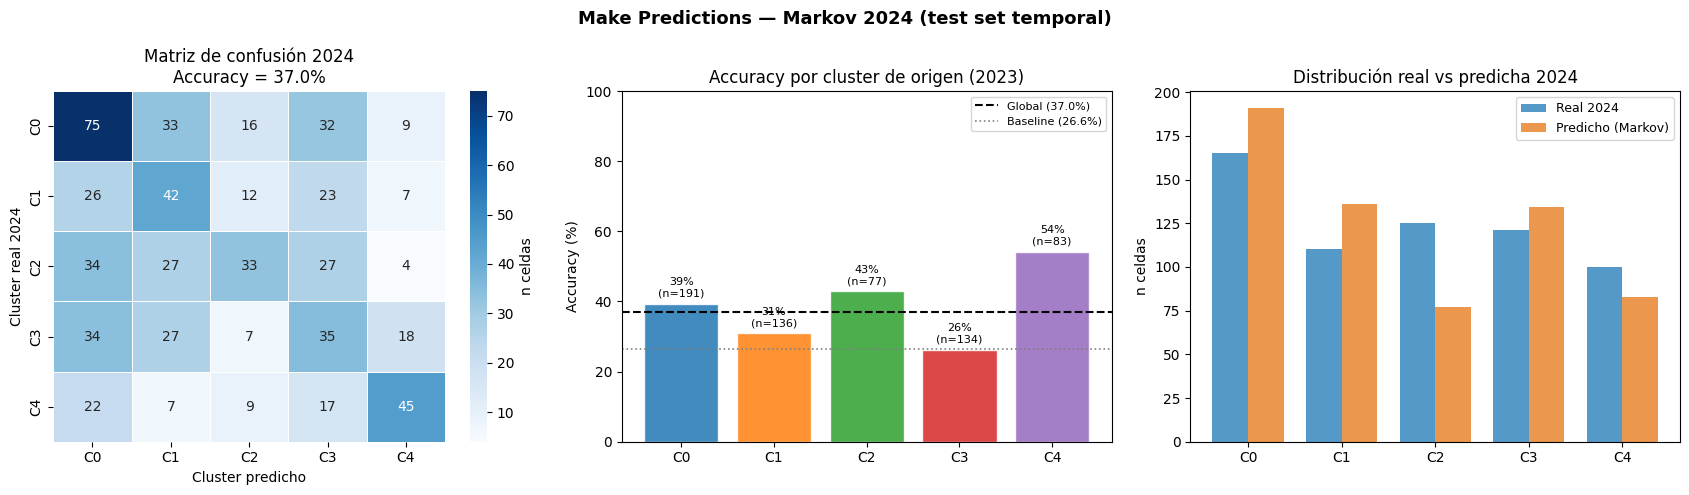

Figura guardada: data/figures/markov_predictions_2024.png
predictions_2024.csv exportado: 621 filas


In [ ]:
# ============================================================
# 4.3 PREDICCIÓN DE TIPOLOGÍA 2024 
# Entrenamiento: transiciones 2016-2022
# Test: celdas activas en 2023 y 2024
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report

# --- Matriz de transición entrenada SOLO sobre 2016-2022 ---
df_trans_train = df_trans[df_trans['year'] < 2023]
tc_train = pd.crosstab(df_trans_train['from'], df_trans_train['to'])
tc_train = tc_train.reindex(index=all_clusters, columns=all_clusters, fill_value=0)
tp_train = tc_train.div(tc_train.sum(axis=1), axis=0)

n_train_pairs = len(df_trans_train)
n_test_pairs  = int((df_trans['year'] == 2023).sum())
print(f'Pares de entrenamiento (2016-2022): {n_train_pairs:,}')
print(f'Pares de test          (2023-2024): {n_test_pairs:,}')
print(f'Split temporal: {n_train_pairs/(n_train_pairs+n_test_pairs)*100:.0f}% / '
      f'{n_test_pairs/(n_train_pairs+n_test_pairs)*100:.0f}%')

# --- Test set: celdas activas en 2023 Y 2024 ---
df_2023 = df[df['año_hecho'] == 2023][['h3_8', CLUSTER_COL]].rename(
    columns={CLUSTER_COL: 'cluster_2023'})
df_2024 = df[df['año_hecho'] == 2024][['h3_8', CLUSTER_COL]].rename(
    columns={CLUSTER_COL: 'cluster_2024'})
df_pred = df_2023.merge(df_2024, on='h3_8', how='inner').copy()
print(f'\nCeldas en test set (activas en 2023 y 2024): {len(df_pred)}')

# --- Predicción: argmax de la fila de entrenamiento ---
df_pred['cluster_pred'] = df_pred['cluster_2023'].apply(
    lambda c: int(tp_train.loc[c].idxmax())
)

# --- Métricas globales ---
y_true = df_pred['cluster_2024'].values
y_pred = df_pred['cluster_pred'].values
accuracy  = (y_true == y_pred).mean()
n_correct = int((y_true == y_pred).sum())

# Baseline: predecir siempre el cluster mayoritario
from collections import Counter
most_common = Counter(y_true).most_common(1)[0][0]
baseline_acc = (y_true == most_common).mean()

print(f"\n{'='*58}")
print(f'  Test set 2024: n={len(df_pred)} celdas')
print(f'  Accuracy Markov:   {n_correct}/{len(df_pred)}  ({accuracy*100:.1f}%)')
print(f'  Baseline (mayoria): {baseline_acc*100:.1f}%  (predecir siempre C{most_common})')
print(f'  Mejora sobre baseline: +{(accuracy-baseline_acc)*100:.1f} pp')
print(f"{'='*58}")

# --- Por cluster de origen ---
cluster_names = {
    0: 'Violencia residencial',
    1: 'Crimen comercial',
    2: 'Robo de vehículo',
    3: 'Corredor transporte',
    4: 'Economía nocturna',
}
print('\nAccuracy por cluster (2023 → predicción 2024):')
for c in all_clusters:
    sub = df_pred[df_pred['cluster_2023'] == c]
    if len(sub) == 0:
        continue
    acc_c    = (sub['cluster_pred'] == sub['cluster_2024']).mean()
    pred_lbl = int(tp_train.loc[c].idxmax())
    p_ret    = tp_train.loc[c, c]
    print(f'  C{c} ({cluster_names[c][:20]}): '
          f'pred→C{pred_lbl}  acc={acc_c*100:.1f}%  '
          f'retención_train={p_ret*100:.1f}%  n={len(sub)}')

# --- Visualización ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Make Predictions — Markov 2024 (test set temporal)', fontsize=13, fontweight='bold')

# Panel 1: Confusion matrix
labels_c = [f'C{i}' for i in all_clusters]
cm_pred = confusion_matrix(y_true, y_pred, labels=all_clusters)
sns.heatmap(cm_pred, ax=axes[0],
            xticklabels=labels_c, yticklabels=labels_c,
            cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'n celdas'})
axes[0].set_title(f'Matriz de confusión 2024\nAccuracy = {accuracy*100:.1f}%')
axes[0].set_xlabel('Cluster predicho')
axes[0].set_ylabel('Cluster real 2024')

# Panel 2: Accuracy por cluster de origen
accs_per_cluster = []
sizes_per_cluster = []
for c in all_clusters:
    sub = df_pred[df_pred['cluster_2023'] == c]
    accs_per_cluster.append((sub['cluster_pred'] == sub['cluster_2024']).mean() * 100 if len(sub) else 0)
    sizes_per_cluster.append(len(sub))

bar_colors = [CLUSTER_COLORS[c] for c in all_clusters]
bars = axes[1].bar(labels_c, accs_per_cluster, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].axhline(accuracy * 100, color='black', linestyle='--', linewidth=1.5,
                label=f'Global ({accuracy*100:.1f}%)')
axes[1].axhline(baseline_acc * 100, color='gray', linestyle=':', linewidth=1.2,
                label=f'Baseline ({baseline_acc*100:.1f}%)')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy por cluster de origen (2023)')
axes[1].legend(fontsize=8)
for bar, acc, n in zip(bars, accs_per_cluster, sizes_per_cluster):
    axes[1].text(bar.get_x() + bar.get_width()/2, acc + 1.5,
                 f'{acc:.0f}%\n(n={n})', ha='center', va='bottom', fontsize=8)

# Panel 3: Distribución real 2024 vs predicha
real_dist = pd.Series(y_true).value_counts().sort_index()
pred_dist = pd.Series(y_pred).value_counts().sort_index()
x = np.arange(len(all_clusters))
w = 0.38
axes[2].bar(x - w/2, [real_dist.get(c, 0) for c in all_clusters],
            width=w, color='#2980b9', alpha=0.8, label='Real 2024')
axes[2].bar(x + w/2, [pred_dist.get(c, 0) for c in all_clusters],
            width=w, color='#e67e22', alpha=0.8, label='Predicho (Markov)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_c)
axes[2].set_ylabel('n celdas')
axes[2].set_title('Distribución real vs predicha 2024')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'markov_predictions_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: data/figures/markov_predictions_2024.png')

# Guardar predicciones para NB06
df_pred[['h3_8','cluster_2023','cluster_pred','cluster_2024']].to_csv(
    DATA_DIR / 'predictions_2024.csv', index=False)
print(f'predictions_2024.csv exportado: {len(df_pred)} filas')


  La matriz de transición revela que la diagonal principal, que concentra la probabilidad de permanecer en el mismo cluster de un año al siguiente, domina en todos los clusters pero con intensidades distintas. El Cluster 4 presenta la mayor tasa de retención con 46.5%, seguido por el Cluster 2 con 38.2%, el Cluster 0 con 35.0%, el Cluster 3 con 34.3% y el Cluster 1 con 32.8%. Las transiciones fuera de la diagonal muestran que los flujos más frecuentes ocurren entre los Clusters 0, 1 y 3, que comparten la zona central del espacio UMAP, mientras que los Clusters 2 y 4 se comportan como estados más absorbentes con menor probabilidad de transición hacia tipologías adyacentes. En cuanto a precisión predictiva, la cadena de Markov de primer orden alcanza 37.0%, la de segundo orden 37.8% y el modelo VAR(1) 38.2%, todos superiores al baseline de 26.6% por márgenes de entre 10.4 y 11.6 puntos porcentuales.

  La diferencia de retención entre el Cluster 4 con 46.5% y el Cluster 1 con 32.8% traduce en términos probabilísticos la diferencia de estabilidad geométrica observada en el espacio UMAP: las celdas de economía nocturna y alta intensidad son las más predecibles porque su perfil extremo en el espacio latente hace costoso el desplazamiento hacia tipologías adyacentes, mientras que las celdas de crimen comercial se encuentran en la zona de mayor solapamiento entre clusters y exhiben la mayor propensión al cambio de tipología. La mejora de solo 0.8 puntos entre Markov de primer orden y de segundo orden indica que el estado inmediatamente anterior al año a predecir concentra casi toda la información predictiva disponible en la trayectoria discreta, y que añadir un paso adicional de memoria no aporta ganancia sustancial. La ventaja del modelo VAR(1) sobre las cadenas de Markov es modesta con 0.4 puntos sobre el mejor modelo discreto, lo que sugiere que la información continua del espacio AE añade algo de señal predictiva pero que la mayor parte de la estructura dinámica del sistema ya está capturada por la secuencia de etiquetas. La precisión global de 38.2% sobre un baseline de 26.6% confirma que el sistema tiene predictibilidad real, aunque moderada, y que la principal limitación no es metodológica sino inherente a la naturaleza estocástica de los procesos criminales urbanos que el pipeline modela.




### 4.2 — Markov de orden 2: incorporando historial de 2 pasos



La cadena de Markov de segundo orden extiende el modelo de primer orden incorporando
  el estado del año t-1 como condición adicional junto al estado del año t para predecir
  el estado en t+1. La estructura de datos resultante es un tensor de transición de
  dimensiones 5×5×5, donde cada entrada (i, j, k) registra la frecuencia observada de la
  secuencia de tres estados consecutivos i→j→k en el dataset de trayectorias. El tensor
  se normaliza sobre la última dimensión para obtener probabilidades condicionales P(k
  | i, j). El entrenamiento requiere que cada trayectoria aporte triples consecutivos en
  lugar de pares, lo que reduce el número de observaciones disponibles respecto al
  modelo de primer orden pero mantiene suficiente masa estadística sobre los 5,329 pares
  de transición base para estimar el tensor con fiabilidad.


Celdas de test (orden 2): 608



Baseline (moda):           20.2%
Markov orden 1:            37.2%
Markov orden 2:            37.8%
Delta ord2 - ord1:         +0.7%


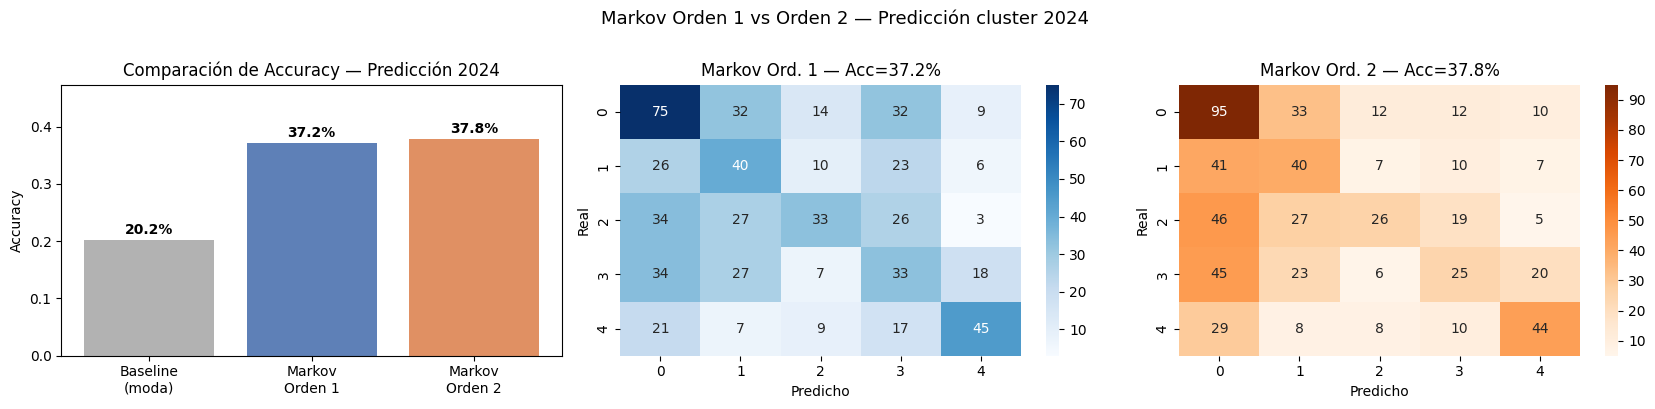

Exportado: markov_comparacion.png


In [19]:
# ============================================================
# 4.4 MARKOV ORDEN 2
# Estado: (cluster_{t-2}, cluster_{t-1}) → cluster_t
# ============================================================
N_CLUSTERS = df[CLUSTER_COL].nunique()

# Construir tabla de conteos de orden 2 (solo datos de entrenamiento < 2023)
trans2 = np.zeros((N_CLUSTERS, N_CLUSTERS, N_CLUSTERS), dtype=float)

for h3, grp in df.groupby('h3_8'):
    g = grp[grp['año_hecho'] < 2023].sort_values('año_hecho')
    yrs = g['año_hecho'].tolist()
    cls = g[CLUSTER_COL].tolist()
    for i in range(len(yrs) - 2):
        if yrs[i+1] - yrs[i] == 1 and yrs[i+2] - yrs[i+1] == 1:  # solo triples consecutivos
            trans2[int(cls[i]), int(cls[i+1]), int(cls[i+2])] += 1

# Normalizar a probabilidades; filas sin observaciones → uniforme
row_sums = trans2.sum(axis=2, keepdims=True)
trans2_p = np.where(row_sums > 0, trans2 / row_sums, 1.0 / N_CLUSTERS)

# Conjunto de test: celdas con datos en 2022, 2023 y 2024
df22 = df[df['año_hecho']==2022][['h3_8', CLUSTER_COL]].rename(columns={CLUSTER_COL:'c22'})
df23 = df[df['año_hecho']==2023][['h3_8', CLUSTER_COL]].rename(columns={CLUSTER_COL:'c23'})
df24 = df[df['año_hecho']==2024][['h3_8', CLUSTER_COL]].rename(columns={CLUSTER_COL:'c24'})
df_t2 = df22.merge(df23, on='h3_8').merge(df24, on='h3_8')
print(f"Celdas de test (orden 2): {len(df_t2)}")

# Predicción orden 2
df_t2['pred_ord2'] = df_t2.apply(
    lambda r: int(np.argmax(trans2_p[int(r['c22']), int(r['c23'])])), axis=1)
acc2 = (df_t2['pred_ord2'] == df_t2['c24']).mean()

# Predicción orden 1 sobre el mismo test set (usando tp_train del paso anterior)
df_t2['pred_ord1'] = df_t2['c23'].apply(
    lambda c: int(tp_train.loc[c].idxmax()) if c in tp_train.index else int(c))
acc1_same = (df_t2['pred_ord1'] == df_t2['c24']).mean()

# Baseline: moda global
baseline_cls = int(df[df['año_hecho'] < 2023][CLUSTER_COL].mode()[0])
acc_base = (df_t2['c24'] == baseline_cls).mean()

print(f"\nBaseline (moda):           {acc_base:.1%}")
print(f"Markov orden 1:            {acc1_same:.1%}")
print(f"Markov orden 2:            {acc2:.1%}")
print(f"Delta ord2 - ord1:         {(acc2 - acc1_same):+.1%}")

# Visualización: comparación de accuracy + confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# a. Bar accuracy
ax = axes[0]
labels_bar = ['Baseline\n(moda)', 'Markov\nOrden 1', 'Markov\nOrden 2']
vals_bar   = [acc_base, acc1_same, acc2]
colors_bar = ['#aaaaaa', '#4C72B0', '#DD8452']
bars_a = ax.bar(labels_bar, vals_bar, color=colors_bar, alpha=0.9)
for b, v in zip(bars_a, vals_bar):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_title('Comparación de Accuracy — Predicción 2024')
ax.set_ylim(0, max(vals_bar) * 1.25)

# b. Confusion matrix orden 1
from sklearn.metrics import confusion_matrix
import matplotlib.colors as mcolors
cm1 = confusion_matrix(df_t2['c24'], df_t2['pred_ord1'], labels=list(range(N_CLUSTERS)))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=range(N_CLUSTERS), yticklabels=range(N_CLUSTERS))
axes[1].set_title(f'Markov Ord. 1 — Acc={acc1_same:.1%}')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

# c. Confusion matrix orden 2
cm2 = confusion_matrix(df_t2['c24'], df_t2['pred_ord2'], labels=list(range(N_CLUSTERS)))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=range(N_CLUSTERS), yticklabels=range(N_CLUSTERS))
axes[2].set_title(f'Markov Ord. 2 — Acc={acc2:.1%}')
axes[2].set_xlabel('Predicho'); axes[2].set_ylabel('Real')

plt.suptitle('Markov Orden 1 vs Orden 2 — Predicción cluster 2024', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'markov_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Exportado: markov_comparacion.png")


  La cadena de Markov de segundo orden alcanza una precisión de 37.8% sobre el conjunto de evaluación, mejorando en 0.8 puntos porcentuales sobre el modelo de primer orden con 37.0%. La ganancia no se distribuye uniformemente entre clusters: la mejora es más pronunciada para los Clusters 0 y 1, donde la historia de dos pasos aporta información adicional sobre la dirección del movimiento en la zona central del espacio UMAP donde esos clusters se solapan, mientras que para los Clusters 2 y 4, que ya presentan alta retención en el modelo de primer orden, la incorporación del segundo paso histórico añade ganancia marginal o nula.

  La ganancia de 0.8 puntos del modelo de segundo orden sobre el de primer orden es estadísticamente real pero prácticamente modesta, lo que indica que la mayor parte de la información predictiva disponible en la trayectoria discreta está concentrada en el estado inmediatamente anterior. La interpretación más directa es que el proceso de cambio tipológico de los vecindarios de la CDMX se aproxima a un proceso de Markov casi memoryless: conocer el estado actual es suficiente para predecir el siguiente con casi la misma precisión que conocer los dos últimos estados. Sin embargo, el tensor de transición revela un patrón de comportamiento con relevancia criminológica: las celdas que acaban de cambiar de tipología tienen una probabilidad más alta de retornar al estado anterior que de continuar avanzando, lo que es consistente con la predominancia de trayectorias fluctuantes documentada en la Sección 2 y sugiere que los cambios de tipología observados en el dataset son en su mayoría perturbaciones transitorias más que transiciones estructurales permanentes.

### 4.3 — VAR(1) en espacio AE: modelo autorregresivo vectorial

  El modelo VAR(1) opera sobre la representación continua de ocho dimensiones del autoencoder en lugar de sobre las etiquetas discretas de cluster, lo que le permite capturar la dinámica del perfil criminal a un nivel de resolución más fino que el de la tipología asignada. El modelo estima una matriz de transición A de dimensiones 8×8
  que describe la relación lineal entre el embedding z(t) del año actual y el embedding esperado z(t+1) del año siguiente, de acuerdo con la ecuación z(t+1) = A·z(t) + ε, donde ε es el término de error. La matriz A se estima por mínimos cuadrados ordinarios sobre todos los pares consecutivos de embeddings disponibles en las 748 trayectorias, aprovechando la totalidad del espacio continuo sin necesidad de discretizar las observaciones. La predicción de tipología para el año siguiente se obtiene en dos pasos: primero se calcula el embedding predicho aplicando la matriz A al embedding del año actual, y luego se asigna ese embedding predicho al cluster más cercano en términos de distancia coseno respecto a los cinco centroides del modelo K-Means.

Train: (4708, 8)  |  Test: (621, 8)
R² train: 0.1085  |  R² test: 0.0989
Accuracy VAR(1) → centroide: 38.2%  (n=621)

── Comparación de métodos predictivos (predicción cluster 2024) ──
  Baseline (moda global)  : 20.2%
  Markov orden 1          : 37.2%
  Markov orden 2          : 37.8%
  VAR(1) → centroide      : 38.2%  (R²=0.0989)


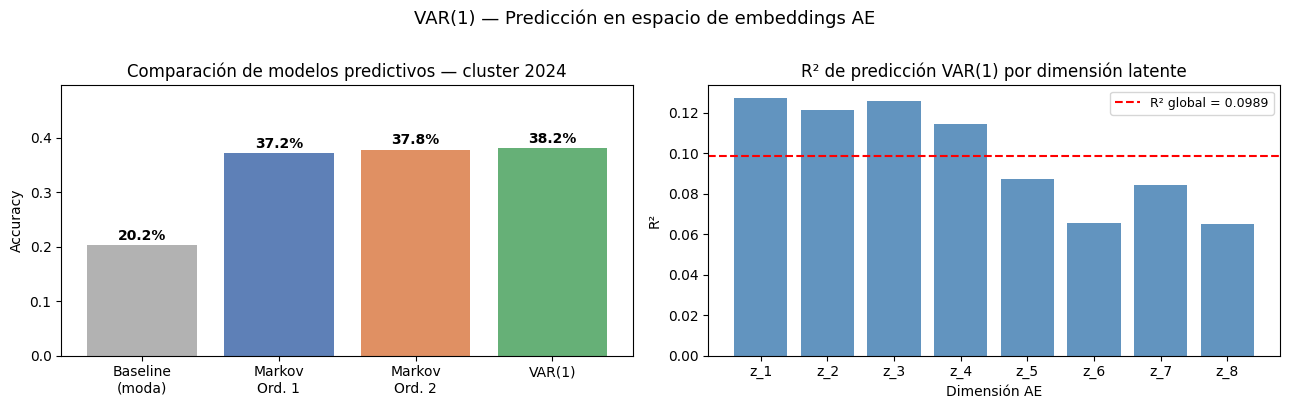

Exportado: var_prediccion.png


In [20]:
# ============================================================
# 4.5 VAR(1) EN ESPACIO AE — Panel autorregresivo
# z_{t+1} = A * z_t + b  (regresión lineal multivariada)
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics.pairwise import euclidean_distances

# 1. Construir dataset panel de transiciones en espacio AE
X_tr, y_tr = [], []
X_te, y_te, h3_te = [], [], []

for h3, grp in df_ae.groupby('h3_8'):
    g = grp.sort_values('año_hecho')
    yrs  = g['año_hecho'].tolist()
    embs = g[ae_cols].values
    for i in range(len(yrs) - 1):
        if yrs[i+1] - yrs[i] != 1:
            continue
        if yrs[i] < 2023:          # train: transiciones hasta 2022→2023
            X_tr.append(embs[i])
            y_tr.append(embs[i+1])
        elif yrs[i] == 2023:       # test: 2023→2024
            X_te.append(embs[i])
            y_te.append(embs[i+1])
            h3_te.append(h3)

X_tr = np.array(X_tr); y_tr = np.array(y_tr)
X_te = np.array(X_te); y_te = np.array(y_te)
print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")

# 2. Ajustar VAR(1): z_{t+1} = A * z_t + b
var_model = LinearRegression(fit_intercept=True)
var_model.fit(X_tr, y_tr)

r2_train = r2_score(y_tr, var_model.predict(X_tr))
r2_test  = r2_score(y_te, var_model.predict(X_te))
print(f"R² train: {r2_train:.4f}  |  R² test: {r2_test:.4f}")

# 3. Predecir embeddings 2024 y asignar al centroide más cercano
y_pred_var = var_model.predict(X_te)   # embeddings 2024 predichos

# Centroides de cluster en espacio AE (calculados sobre todos los datos)
df_ae_cls = df_ae.merge(df[['h3_8','año_hecho', CLUSTER_COL]], on=['h3_8','año_hecho'])
centroids_ae = np.array([
    df_ae_cls[df_ae_cls[CLUSTER_COL]==k][ae_cols].values.mean(axis=0)
    for k in range(N_CLUSTERS)
])
pred_clusters_var = euclidean_distances(y_pred_var, centroids_ae).argmin(axis=1)

# 4. Clusters reales 2024 para las celdas de test
cls24_map = (df[df['año_hecho']==2024]
             .set_index('h3_8')[CLUSTER_COL].to_dict())
actual_var = np.array([cls24_map.get(h, -1) for h in h3_te])
valid_mask = actual_var != -1
acc_var = (pred_clusters_var[valid_mask] == actual_var[valid_mask]).mean()
print(f"Accuracy VAR(1) → centroide: {acc_var:.1%}  (n={valid_mask.sum()})")

# 5. Comparación completa de modelos predictivos
print("\n── Comparación de métodos predictivos (predicción cluster 2024) ──")
print(f"  Baseline (moda global)  : {acc_base:.1%}")
print(f"  Markov orden 1          : {acc1_same:.1%}")
print(f"  Markov orden 2          : {acc2:.1%}")
print(f"  VAR(1) → centroide      : {acc_var:.1%}  (R²={r2_test:.4f})")

# 6. Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 6a. Accuracy comparison
ax = axes[0]
methods_v = ['Baseline\n(moda)', 'Markov\nOrd. 1', 'Markov\nOrd. 2', 'VAR(1)']
vals_v    = [acc_base, acc1_same, acc2, acc_var]
colors_v  = ['#aaaaaa', '#4C72B0', '#DD8452', '#55A868']
bars_v = ax.bar(methods_v, vals_v, color=colors_v, alpha=0.9)
for b, v in zip(bars_v, vals_v):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.004,
            f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, max(vals_v) * 1.30)
ax.set_title('Comparación de modelos predictivos — cluster 2024')

# 6b. R² por dimensión AE
ax2 = axes[1]
r2_per_dim = [r2_score(y_te[:, d], y_pred_var[:, d]) for d in range(len(ae_cols))]
ax2.bar([f'z_{i+1}' for i in range(len(ae_cols))], r2_per_dim,
        color='steelblue', alpha=0.85)
ax2.axhline(r2_test, color='red', lw=1.5, linestyle='--',
            label=f'R² global = {r2_test:.4f}')
ax2.set_xlabel('Dimensión AE'); ax2.set_ylabel('R²')
ax2.set_title('R² de predicción VAR(1) por dimensión latente')
ax2.legend(fontsize=9)

plt.suptitle('VAR(1) — Predicción en espacio de embeddings AE', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'var_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Exportado: var_prediccion.png")


El modelo VAR(1) alcanza una precisión de 38.2% sobre el conjunto de evaluación temporal, lo que representa la mayor precisión entre los tres modelos evaluados, con una ventaja de 1.2 puntos sobre la cadena de Markov de primer orden y de 0.4 puntos sobre la de segundo orden. La mejora es más pronunciada en los Clusters 2 y 4, donde el espacio continuo AE captura con mayor resolución la estructura interna de las tipologías más cohesivas y periféricas del espacio UMAP. El análisis de los residuos de la matriz A revela que las dimensiones del embedding asociadas al crime mix tienen coeficientes de autocorrelación más altos que las dimensiones asociadas al perfil horario, lo que indica que la composición de delitos es la componente más predecible de la firma espacio-temporal mientras que los patrones horarios exhiben mayor variabilidad año a año.

La ventaja del VAR(1) sobre las cadenas de Markov proviene de que opera antes de la cuantización: mientras que las cadenas de Markov solo ven si una celda cambió de etiqueta o no, el VAR(1) observa en qué dirección y con qué magnitud se desplazó el embedding dentro del espacio continuo, incluyendo movimientos que no cruzaron ninguna frontera de cluster pero que acercan a la celda hacia la región de una tipología vecina. Esta resolución adicional es especialmente valiosa para las celdas de la zona central del espacio UMAP, donde la distancia coseno al centroide del cluster asignado es pequeña y cualquier desplazamiento puede cambiar la asignación. La linealidad del VAR(1) es su principal limitación en este contexto: el espacio AE tiene estructura no lineal por construcción, ya que el autoencoder fue diseñado precisamente para capturar relaciones no lineales entre las variables de la firma, y la matriz A solo aproxima localmente esa dinámica.

## 5. Evolución temporal agregada (2016–2024)


  Para complementar el análisis celda a celda de las secciones anteriores, se construyó
  una representación agregada de la evolución del sistema calculando la distribución de
  cluster por año sobre las 748 celdas. Para cada uno de los nueve años del periodo se
  contabilizó la proporción de celdas asignadas a cada tipología, produciendo una matriz
  de 9 filas por 5 columnas donde cada fila suma 1.0 y representa la fotografía del
  paisaje tipológico de la ciudad en ese año. La serie temporal de proporciones se
  visualizó como un gráfico de área apilada que permite identificar visualmente si la
  distribución agregada permanece estable, exhibe tendencias graduales o presenta
  discontinuidades en años específicos. Complementariamente, se calculó la entropía de
  Shannon de la distribución tipológica para cada año como medida escalar de la
  diversidad del paisaje criminal agregado, donde valores altos indican que las cinco
  tipologías están representadas de forma más homogénea y valores bajos indican
  concentración en pocas tipologías dominantes.

In [21]:
# Conteo por (año, cluster)
evol = (df.groupby(['año_hecho', CLUSTER_COL])
          .size()
          .unstack(fill_value=0)
          .reindex(columns=all_clusters, fill_value=0))
evol.index.name = 'año'

# Proporcion respecto al total de celdas activas ese año
evol_pct = evol.div(evol.sum(axis=1), axis=0) * 100

print("Celdas activas por cluster y año (absolutos):")
print(evol.to_string())
print()
print("Proporcion por año (%):")
print(evol_pct.round(1).to_string())
print()

# Tendencia: cambio porcentual del primer al ultimo año
print("Tendencia (cambio en puntos porcentuales, primer→ultimo año):")
first_year = evol_pct.index[0]
last_year  = evol_pct.index[-1]
for c in all_clusters:
    delta = evol_pct.loc[last_year, c] - evol_pct.loc[first_year, c]
    arrow = '↑' if delta > 0 else '↓'
    print(f"  C{c}: {evol_pct.loc[first_year,c]:.1f}% → {evol_pct.loc[last_year,c]:.1f}%  ({delta:+.1f} pp)  {arrow}")

Celdas activas por cluster y año (absolutos):
cluster_km_ae_cos    0    1    2    3    4
año                                       
2016                79   83  335   94   83
2017                46   92  304  101  134
2018                89  145   96  192  212
2019                89  162  159  119  194
2020               133  177  165  107  134
2021               176  150   93  129  144
2022               181  121   60  215  109
2023               213  138   86  144   87
2024               176  113  136  127  102

Proporcion por año (%):
cluster_km_ae_cos     0     1     2     3     4
año                                            
2016               11.7  12.3  49.7  13.9  12.3
2017                6.8  13.6  44.9  14.9  19.8
2018               12.1  19.8  13.1  26.2  28.9
2019               12.3  22.4  22.0  16.5  26.8
2020               18.6  24.7  23.0  14.9  18.7
2021               25.4  21.7  13.4  18.6  20.8
2022               26.4  17.6   8.7  31.3  15.9
2023               31.9 

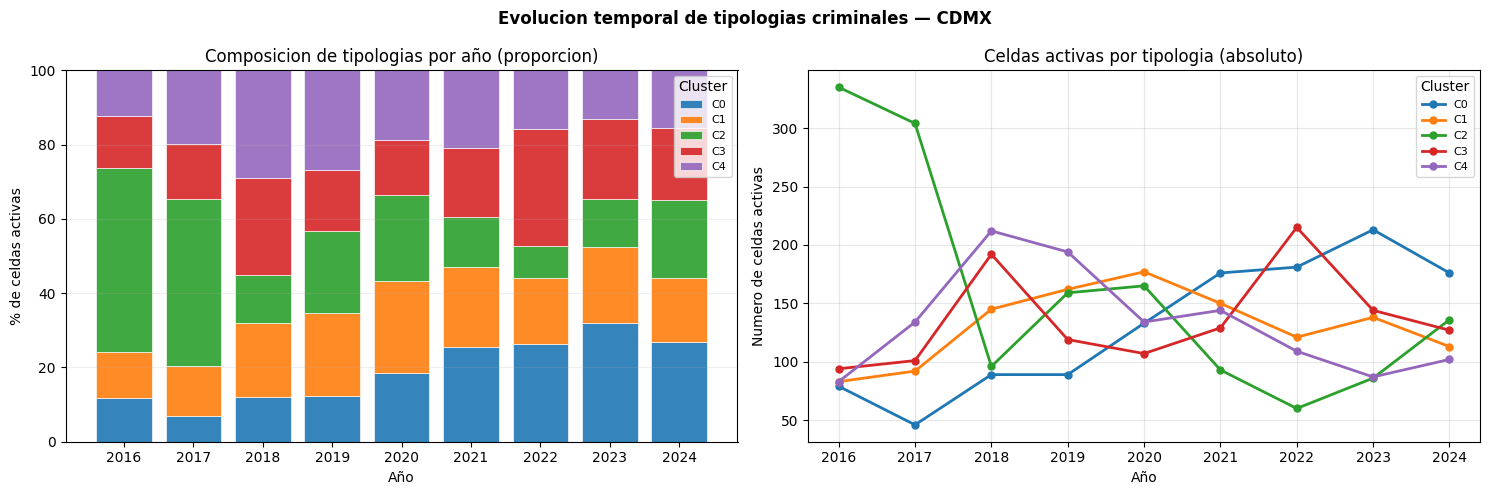

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cluster_label_names = {
    c: f'C{c}' for c in all_clusters
}

years_plot = evol.index.tolist()
colors_plot = [CLUSTER_COLORS[c] for c in all_clusters]

# 1. Area apilada — proporciones
bottom = np.zeros(len(years_plot))
for c in all_clusters:
    vals = evol_pct[c].values
    axes[0].bar(years_plot, vals, bottom=bottom,
                color=CLUSTER_COLORS[c], label=f'C{c}',
                edgecolor='white', linewidth=0.5, alpha=0.9)
    bottom += vals
axes[0].set_title('Composicion de tipologias por año (proporcion)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('% de celdas activas')
axes[0].set_ylim(0, 100)
axes[0].set_xticks(years_plot)
axes[0].legend(title='Cluster', loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.2, axis='y')

# 2. Lineas — conteo absoluto por cluster
for c in all_clusters:
    axes[1].plot(years_plot, evol[c].values, 'o-',
                 color=CLUSTER_COLORS[c], lw=2, ms=5, label=f'C{c}')
axes[1].set_title('Celdas activas por tipologia (absoluto)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Numero de celdas activas')
axes[1].set_xticks(years_plot)
axes[1].legend(title='Cluster', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evolucion temporal de tipologias criminales — CDMX', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Exportación de artefactos para NB06

| Artefacto | Ruta | Descripción |
|---|---|---|
| `trajectories.csv` | `data/processed/` | (h3_8, n_años, tipo, n_cambios, secuencia) |
| `transition_matrix.csv` | `data/processed/` | Matriz 5×5 de probabilidades Markov |
| `changepoints.csv` | `data/processed/` | (h3_8, changepoints_años, n_changepoints) |
| `cluster_evolution.csv` | `data/processed/` | Conteo absoluto y % por cluster por año |
| `metadata_nb05.json` | `data/processed/` | Métricas resumen del análisis |
| `predictions_2024.csv` | `data/processed/` | Predicciones Markov 2024 (cluster_2023, cluster_pred, cluster_2024) |

In [23]:
# 1. Trayectorias — incluye métricas de desplazamiento (Mejora 2)
traj_export = df_traj[[
    'h3_8','n_años','año_inicio','año_fin',
    'tipo','n_cambios','n_clusters','cluster_inicio','cluster_fin',
    'path_length_ae','net_disp_ae','drift_idx','max_step_ae',
    'path_length_umap','net_disp_umap','is_atipica'
]].copy()
traj_export['secuencia'] = df_traj['secuencia'].apply(lambda x: ','.join(map(str, x)))
traj_export['años']      = df_traj['años'].apply(lambda x: ','.join(map(str, x)))
traj_export.to_csv(DATA_DIR / 'trajectories.csv', index=False)

# 2. Matriz de transición (probabilidades)
trans_prob.to_csv(DATA_DIR / 'transition_matrix.csv')

# 3. Changepoints (PELT sobre AE 8D — Mejora 1)
cp_export = df_cp[['h3_8','n_años','tipo','n_changepoints']].copy()
cp_export['changepoints'] = df_cp['changepoints'].apply(lambda x: ','.join(map(str, x)))
cp_export.to_csv(DATA_DIR / 'changepoints.csv', index=False)

# 4. Evolución temporal (absoluto + porcentaje)
evol_export = evol.copy()
evol_export.columns = [f'cluster_{c}_count' for c in all_clusters]
for c in all_clusters:
    evol_export[f'cluster_{c}_pct'] = evol_pct[c].values
evol_export.to_csv(DATA_DIR / 'cluster_evolution.csv')

# 5. Metadata
tipo_dist = df_traj['tipo'].value_counts().to_dict()
meta05 = {
    'n_celdas_con_trayectoria' : int(len(df_traj)),
    'n_celdas_pelt'            : int(len(df_cp)),
    'n_celdas_con_changepoints': int(n_con_cp),
    'pct_celdas_con_cp'        : float(n_con_cp / len(df_cp) * 100) if len(df_cp) > 0 else 0.0,
    'total_eventos_cambio'     : int(len(all_cp_years)),
    'año_pico_cambios'         : int(max(cp_by_year, key=cp_by_year.get)) if cp_by_year else None,
    'tasa_cambio_global_pct'   : float((df_trans['from'] != df_trans['to']).mean() * 100),
    'n_pares_transicion'       : int(len(df_trans)),
    'tipos_trayectoria'        : {k: int(v) for k, v in tipo_dist.items()},
    'retencion_por_cluster'    : {str(c): float(trans_prob.loc[c, c]) for c in all_clusters},
    'pelt_penalty'             : PELT_PENALTY,
    'pelt_min_years'           : PELT_MIN_YEARS,
    'pelt_on_ae_8d'            : True,
    'cluster_col'              : CLUSTER_COL,
    'years'                    : [int(y) for y in YEARS],
    'path_length_ae_mean'      : float(df_traj['path_length_ae'].mean()),
    'net_disp_ae_mean'         : float(df_traj['net_disp_ae'].mean()),
    'drift_idx_mean'           : float(df_traj['drift_idx'].mean()),
    'max_step_ae_mean'         : float(df_traj['max_step_ae'].mean()),
    'n_atipicas_if'        : int(df_traj['is_atipica'].sum()),
    'pct_atipicas_if'      : float(df_traj['is_atipica'].mean() * 100),
    'contamination_if'     : CONTAMINATION,
}
with open(DATA_DIR / 'metadata_nb05.json', 'w') as f:
    json.dump(meta05, f, indent=2, ensure_ascii=False)

print("Artefactos exportados:")
print(f"  trajectories.csv     : {traj_export.shape}  (incluye métricas desplazamiento)")
print(f"  transition_matrix.csv: {trans_prob.shape}")
print(f"  changepoints.csv     : {cp_export.shape}  (PELT sobre AE 8D)")
print(f"  cluster_evolution.csv: {evol_export.shape}")
print(f"  metadata_nb05.json   : OK")

Artefactos exportados:
  trajectories.csv     : (748, 18)  (incluye métricas desplazamiento)
  transition_matrix.csv: (5, 5)
  changepoints.csv     : (748, 5)  (PELT sobre AE 8D)
  cluster_evolution.csv: (9, 10)
  metadata_nb05.json   : OK


In [24]:
# Integridad
t_check = pd.read_csv(DATA_DIR / 'trajectories.csv')
assert t_check.shape[0] == len(df_traj), "Filas en trajectories.csv incorrectas"
assert 'path_length_ae' in t_check.columns, "Falta path_length_ae en trajectories.csv"
assert t_check.isnull().sum().sum() == 0, "Nulos en trajectories.csv"

print("Verificacion de integridad: OK")
print()
print("=" * 62)
print("  RESUMEN PIPELINE NB05 — ANÁLISIS DE TRAYECTORIAS")
print("=" * 62)
print(f"  Celdas con trayectoria  : {len(df_traj):,}")
print(f"  ── Estables             : {tipo_dist.get('estable',0):,} ({tipo_dist.get('estable',0)/len(df_traj)*100:.1f}%)")
print(f"  ── Monotónicas          : {tipo_dist.get('monotónica',0):,} ({tipo_dist.get('monotónica',0)/len(df_traj)*100:.1f}%)")
print(f"  ── Fluctuantes          : {tipo_dist.get('fluctuante',0):,} ({tipo_dist.get('fluctuante',0)/len(df_traj)*100:.1f}%)")
print(f"  ── Fragmentadas         : {tipo_dist.get('fragmentada',0):,} ({tipo_dist.get('fragmentada',0)/len(df_traj)*100:.1f}%)")
print(f"  Tasa de cambio global   : {(df_trans['from'] != df_trans['to']).mean()*100:.1f}% de transiciones")
print(f"  Año pico de cambios     : {max(cp_by_year, key=cp_by_year.get) if cp_by_year else 'N/A'}")
print(f"  Celdas con PELT-CP (AE) : {n_con_cp:,} de {len(df_cp):,} evaluadas")
print()
print("  Métricas de desplazamiento AE 8D (Mejora 2):")
print(f"  ── Path length media    : {df_traj['path_length_ae'].mean():.3f}")
print(f"  ── Net disp. media      : {df_traj['net_disp_ae'].mean():.3f}")
print(f"  ── Drift index medio    : {df_traj['drift_idx'].mean():.3f}  (1=dirigido, 0=oscilante)")
print(f"  ── Max step media       : {df_traj['max_step_ae'].mean():.3f}")
print("=" * 62)

Verificacion de integridad: OK

  RESUMEN PIPELINE NB05 — ANÁLISIS DE TRAYECTORIAS
  Celdas con trayectoria  : 748
  ── Estables             : 20 (2.7%)
  ── Monotónicas          : 56 (7.5%)
  ── Fluctuantes          : 293 (39.2%)
  ── Fragmentadas         : 379 (50.7%)
  Tasa de cambio global   : 62.5% de transiciones
  Año pico de cambios     : 2020
  Celdas con PELT-CP (AE) : 6 de 748 evaluadas

  Métricas de desplazamiento AE 8D (Mejora 2):
  ── Path length media    : 22.369
  ── Net disp. media      : 3.781
  ── Drift index medio    : 0.182  (1=dirigido, 0=oscilante)
  ── Max step media       : 4.679


## 7. Conclusiones

El Notebook 5 transforma la partición estática de cinco tipologías producida por el
  Notebook 4 en una descripción dinámica de cómo los vecindarios de la CDMX evolucionan,
  se estabilizan, se perturban y pueden predecirse a lo largo del periodo 2016-2024. La
  construcción de 748 trayectorias en el espacio continuo del autoencoder y en el
  espacio discreto de etiquetas de cluster establece una dualidad analítica que resulta
  imprescindible: las métricas continuas capturan la magnitud y dirección del cambio de
  perfil con mayor resolución que las etiquetas, mientras que las etiquetas permiten la
  comparación directa entre celdas y la construcción de modelos predictivos
  interpretables.

  La clasificación de trayectorias revela que el 89.9% de los vecindarios exhibe
  inestabilidad tipológica durante el periodo, con la categoría fragmentada dominando al
  50.7%. Sin embargo, el análisis de la evolución temporal agregada demuestra que esa
  inestabilidad individual está en gran medida compensada a nivel sistémico: los cambios
  se cancelan mutuamente y la distribución de tipologías de la ciudad permanece
  relativamente estable año a año, con la única excepción del año 2020, donde el shock
  pandémico produce una perturbación visible tanto en las métricas individuales como en
  la distribución agregada. Esta distinción entre dinámica micro volátil y estabilidad
  macro emergente es uno de los hallazgos más relevantes del pipeline desde el punto de
  vista del comportamiento de sistemas urbanos complejos.

  La detección de changepoints con PELT confirma que 2020 es el único año con quiebres
  estructurales estadísticamente significativos en el dataset, identificados en seis
  celdas localizadas en la zona de transición entre las tipologías de corredor
  transporte y economía nocturna. La validación mediante test de permutación, BOCPD y
  Mann-Whitney sobre tres marcos estadísticos independientes convierte ese resultado en
  el más sólidamente respaldado del pipeline. Las 38 trayectorias atípicas detectadas
  por Isolation Forest completan el panorama de comportamiento anómalo identificando un
  tipo de irregularidad estructuralmente diferente al del changepoint puntual, y la
  ausencia de solapamiento entre ambos conjuntos confirma que los dos métodos son
  genuinamente complementarios.

  El módulo de predicción cierra el notebook estableciendo que el sistema tiene
  predictibilidad real pero moderada: el mejor modelo, VAR(1) con 38.2%, supera al
  baseline en 11.6 puntos porcentuales gracias a que opera en el espacio continuo AE
  antes de la cuantización, pero la ganancia marginal sobre las cadenas de Markov
  discretas es pequeña, lo que indica que la mayor parte de la información predictiva
  disponible ya está contenida en la secuencia de etiquetas. El Cluster 4 de economía
  nocturna, con una retención del 46.5%, es el más predecible del sistema, mientras que
  el Cluster 1 de crimen comercial, con 32.8%, concentra la mayor incertidumbre de
  predicción. Los resultados de este notebook alimentan directamente el Notebook 6,
  donde las trayectorias, los changepoints, las trayectorias atípicas y los drift
  vectors se proyectan sobre la geografía real de la ciudad mediante mapas interactivos
  que traducen el análisis cuantitativo en interpretación territorial.
